## 0. Off-axis projection, what this page gives you

Every map on this page comes out of one function call:

`projection(obj, var, unit; <view>, <framing>, <binning>, <pxsize>)`

Off-axis adds exactly one thing to the [axis-aligned page](06_hydro_Projection.md): orientation.
Everything you already know, `center`, `range_unit`, `pxsize`, `weighting` and units, works
unchanged.

There are five knobs. Each one gets its own chapter below.

| knob | keywords | chapter |
|---|---|---|
| view | `direction`, `inclination`/`azimuth`/`axis`, `los` | 1, 3 |
| framing | `fov`/`fov_unit`/`aperture`, `xrange`/`yrange`/`zrange` with `center` | 4 |
| quantity | `var`/`unit` lists, `weighting` | 5 |
| placement | `binning`, where the default is already the accurate one | 6 |
| output | `m.maps`, `getextent`, camera metadata | 1, 10 |

Everything on this page uses one dataset, `RAMSES/spiral_clumps` output 100: about 590 thousand
cells, levels 5 to 7, in a 100 kpc box. The page runs 36 projection calls across 25 code cells and
draws 8 figures.

The limitations are collected in Appendix A at the end, so nothing on this page points forward to
them.

## 1. Your first off-axis view

"A projection is a camera. The data never moves, only the camera does. Two keywords prove it."

Then, BEFORE the code, the first of the three admitted inline caveats:

!!! warning "`direction=:faceon` needs `center` on the object"
    `:faceon`/`:edgeon` (and `axis=:angmom`) derive the orientation from the **angular momentum of the loaded data about `center`**. `center` defaults to `[0.,0.,0.]`, the box **corner**, and L about a corner is dominated by the lever arm of the whole box. You get a plausible-looking tilted galaxy, no error and no warning. Always pass `center=[:bc]` (or the object's own centre). Detection: edge-on, `:vlos` must be antisymmetric about the minor axis (Chapter 7).


In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera, CairoMakie, Statistics
CairoMakie.activate!(type="png")

info = getinfo(100, joinpath(MERA_EXAMPLES,
                "RAMSES/spiral_clumps"), verbose=false)
gas  = gethydro(info, verbose=false, show_progress=false)

println("cells loaded : ", length(gas.data))
println("box length   : ", info.boxlen, " kpc")
println("levels       : ", gas.lmin, " – ", gas.lmax)
println("threads      : ", Threads.nthreads())



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0 | Julia 1.12.7 | 4 threads



cells loaded : 590311


box length   : 100.0 kpc
levels       : 3 – 7
threads      : 4


In [2]:
# ── figure code from here: panels, overlays, colorbars, no new Mera concepts ──
# ONE helper, used by every figure in this notebook. It encodes the rules that make a
# comparison honest: physical axes in kpc, DataAspect, no interpolation, an explicit
# NaN colour, and an optional SHARED colour range.
function showmap!(ax, m, key; logscale=true, cmap=:inferno, crange=nothing)
    A = Float64.(m.maps[key])
    A = logscale ? log10.(replace(A, 0.0 => NaN)) : A
    e = getextent(m, :kpc)
    xs = range(e[1], e[2], length=size(A,1))
    ys = range(e[3], e[4], length=size(A,2))
    hm = heatmap!(ax, xs, ys, A; colormap=cmap, nan_color=:black, interpolate=false,
                  colorrange = crange === nothing ? Makie.automatic : crange)
    ax.aspect = DataAspect()
    return hm
end

# shared colour range across a set of maps (2nd percentile → max), so panels are comparable
function sharedrange(ms, key; logscale=true)
    v = reduce(vcat, [vec(Float64.(m.maps[key])) for m in ms])
    v = logscale ? log10.(filter(x -> x > 0, v)) : filter(isfinite, v)
    (quantile(v, 0.02), maximum(v))
end

function maprow(ms, key, titles; clabel="log10 Σ  [M⊙/pc²]", cmap=:inferno,
                crange=nothing, logscale=true)
    n = length(ms); fig = Figure(size=(330n + 110, 380)); hm = nothing
    for i in 1:n
        ax = Axis(fig[1,i], title=titles[i], xlabel="x' [kpc]",
                  ylabel = i == 1 ? "y' [kpc]" : "")
        i > 1 && hideydecorations!(ax, grid=false)
        hm = showmap!(ax, ms[i], key; logscale=logscale, cmap=cmap, crange=crange)
    end
    Colorbar(fig[1, n+1], hm, label=clabel)
    fig
end


maprow (generic function with 1 method)

[Mera] Hint: getvar(:lx) has no `vcenter` — velocities are in the BOX frame.


             Pass vcenter=:auto for an object with bulk motion (`center=` sets the origin,
             `vcenter=` the frame). On a halo streaming at ~200 km/s this shifted |J| by 34 %.
             (shown once per session; verbose(false) silences Mera's messages)


line of sight  ŵ = 

[0.011, 0.02, -1.0]
image up       û = [1.0, -0.0, 0.011]
projection centre (box fraction) = [0.5, 0.5, 0.5]
frame: (147, 147)  and  (147, 147)


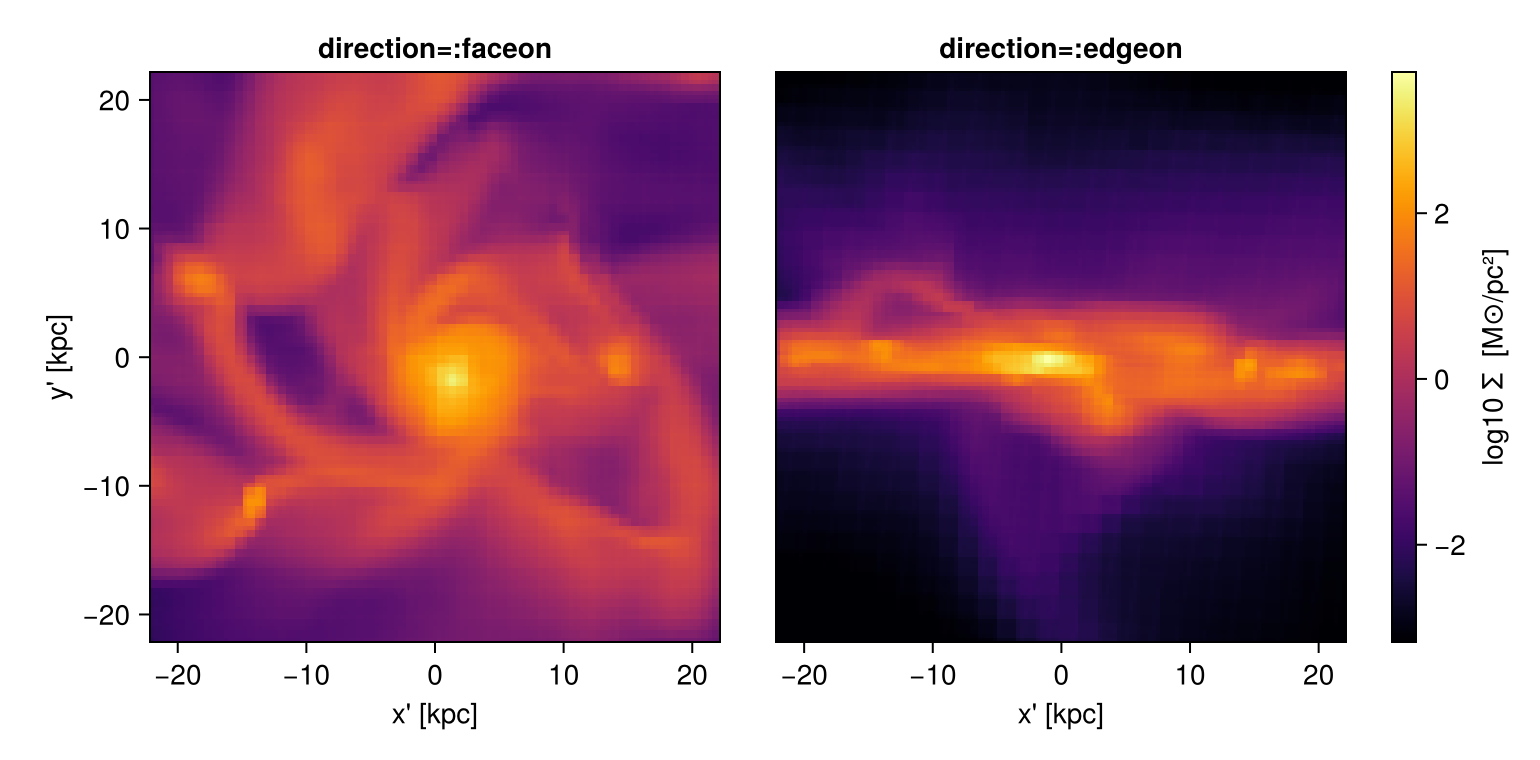

In [3]:
# ONE window, reused by every chapter, so the only thing that changes between cells
# is the keyword being taught.
win = (center=[:bc], fov=22, fov_unit=:kpc, aperture=:square,
       pxsize=[0.3, :kpc], verbose=false, show_progress=false)

fo = projection(gas, :sd, :Msol_pc2; direction=:faceon, win...)
eo = projection(gas, :sd, :Msol_pc2; direction=:edgeon, win...)

println("line of sight  ŵ = ", round.(fo.los, digits=3))
println("image up       û = ", round.(fo.up,  digits=3))
println("projection centre (box fraction) = ", round.(fo.center, digits=3))
println("frame: ", size(fo.maps[:sd]), "  and  ", size(eo.maps[:sd]))

cr = sharedrange([fo, eo], :sd)
maprow([fo, eo], :sd, ["direction=:faceon", "direction=:edgeon"]; crange=cr)


Read the output back:

- `m.maps` is a dict of 2-D arrays; `m.maps[:sd]` is the surface density in `Msol_pc2`.
- `getextent(m, :kpc)` returns `[xmin, xmax, ymin, ymax]` **in the image plane**, the raw `m.extent` is in code units, so always convert.
- `m.los`, `m.up`, `m.cam_right` are the camera basis the call actually used; `m.direction` reads `:offaxis`.

That `los = [0, 0, 1]`-ish vector is not a coincidence you chose, it is the disc's angular momentum axis, computed from your data about your `center`. That is what makes `:faceon` a *measurement*, not a guess.


## 2. What a pixel contains

Before turning more knobs, it is worth being precise about what the numbers in a map *are*.

The camera is **orthographic**: every ray is parallel and the observer sits at infinity. There is
no vanishing point and no perspective, so nothing in the image gets larger by being nearer.

Mera reduces whatever view you specified to a single unit vector **ŵ**, the line of sight, and
completes it to a right-handed orthonormal camera basis **(r̂, û, ŵ)**, image x, image y, and the
viewing direction. Those are the three vectors you read back as `m.cam_right`, `m.up`, `m.los`.
`ŵ` points *out of* the image, toward you: the observer stands on the `+ŵ` side, and the camera
looks along `-ŵ`. Chapter 7 turns that into a sign you can check.

A pixel value is then the integral of the requested quantity along the parallel ray through that
pixel, over the whole depth of the selected data. That single sentence explains most of what
follows: it is why a projection conserves mass, why `zrange` matters as much as `xrange`, and why
a slice, which samples one plane instead of integrating through the volume (Chapter 8), answers
a different question.

`position_angle` is a **roll**: it rotates `(r̂, û)` together about `ŵ`. The line of sight does
not move, so the *scene* is unchanged, but whether the **frame** sees the same gas depends on
the aperture, and it is worth measuring rather than assuming. Rolling by 30° here leaves
`Σ` identical to the last digit with `aperture=:circle` (a disc is roll-invariant) and changes it
by **2.3 %** with `aperture=:square`, because the square crop rotates inside the selection sphere
and its corners sweep across different material.

One consequence deserves to be stated on its own, because the next chapter is built on it: since
the projection is orthographic, **moving the camera away from the galaxy changes nothing**. There
is no camera distance to set. The only control over what lands in frame is the *width of the
frame*, a field of view.

The step-by-step basis construction (the deterministic choice of "up", the Gram to Schmidt
completion, the roll matrix) lives in `?projection`; you do not need it to use any of this.


![Off-axis camera geometry](assets/offaxis/offaxis_geometry_v2.svg)

*Parallel rays, the image plane, and the camera basis `(r̂, û, ŵ)` planted at `center`. Right inset: `inclination` is measured from a **reference axis**, either the box `z` or the object's own angular-momentum axis `L`. They are not the same axis, and choosing the wrong one is the most common way to get a picture that looks right but is not.*


## 3. Choosing the view

**Observer vocabulary → Mera keywords** (the primary artefact of this chapter):

| you want | you say | Mera |
|---|---|---|
| a disc seen flat / on its side | face-on / edge-on | `direction=:faceon` / `:edgeon` |
| a specific inclination *i* | i = 60° | `inclination=60, axis=:angmom` |
| a specific position angle on the sky | PA = 30° | `position_angle=30` |
| a known viewing vector | ŵ = (1,1,1) | `los=[1,1,1]` |
| spherical camera angles | θ, φ | `theta=`, `phi=` |
| spin the object about its own axis | *(no observational counterpart)* | `azimuth=` |

`azimuth` rotates the object about its own spin axis. For an axisymmetric disc it is unobservable, it is a *movie* parameter, not a modelling one, which is why it earns no static panel here and reappears in Chapter 9.

**Reference axis.** `axis=:z` (default) tilts away from the box z-axis; `axis=:angmom` tilts away from the disc's own L, computed about `center`. `axis=[vx,vy,vz]` takes an explicit axis. `direction=:faceon/:edgeon` already imply `:angmom`, so combining them with `axis=` is an `ArgumentError`.

**Exactly one view specifier.** `los` | `inclination`/`azimuth` | `theta`/`phi` | `direction=:faceon/:edgeon` are mutually exclusive; giving two raises immediately. `up=` and `position_angle=` are *modifiers* and combine with any of them.

**Angles are degrees by default** (`angle_unit=:rad` to switch).


max |ŵ_faceon − ŵ_inc0|     = 0.0
angle(û_faceon, û_inc0)     = 

90.0°
max |Σ_faceon − Σ_inc0|     = 2407.1


max |Σ_faceon − Σ_inc0,PA=-90| = 4.433786671143025e-11
inclination + los         

→ ArgumentError
direction=:faceon + axis  

→ ArgumentError


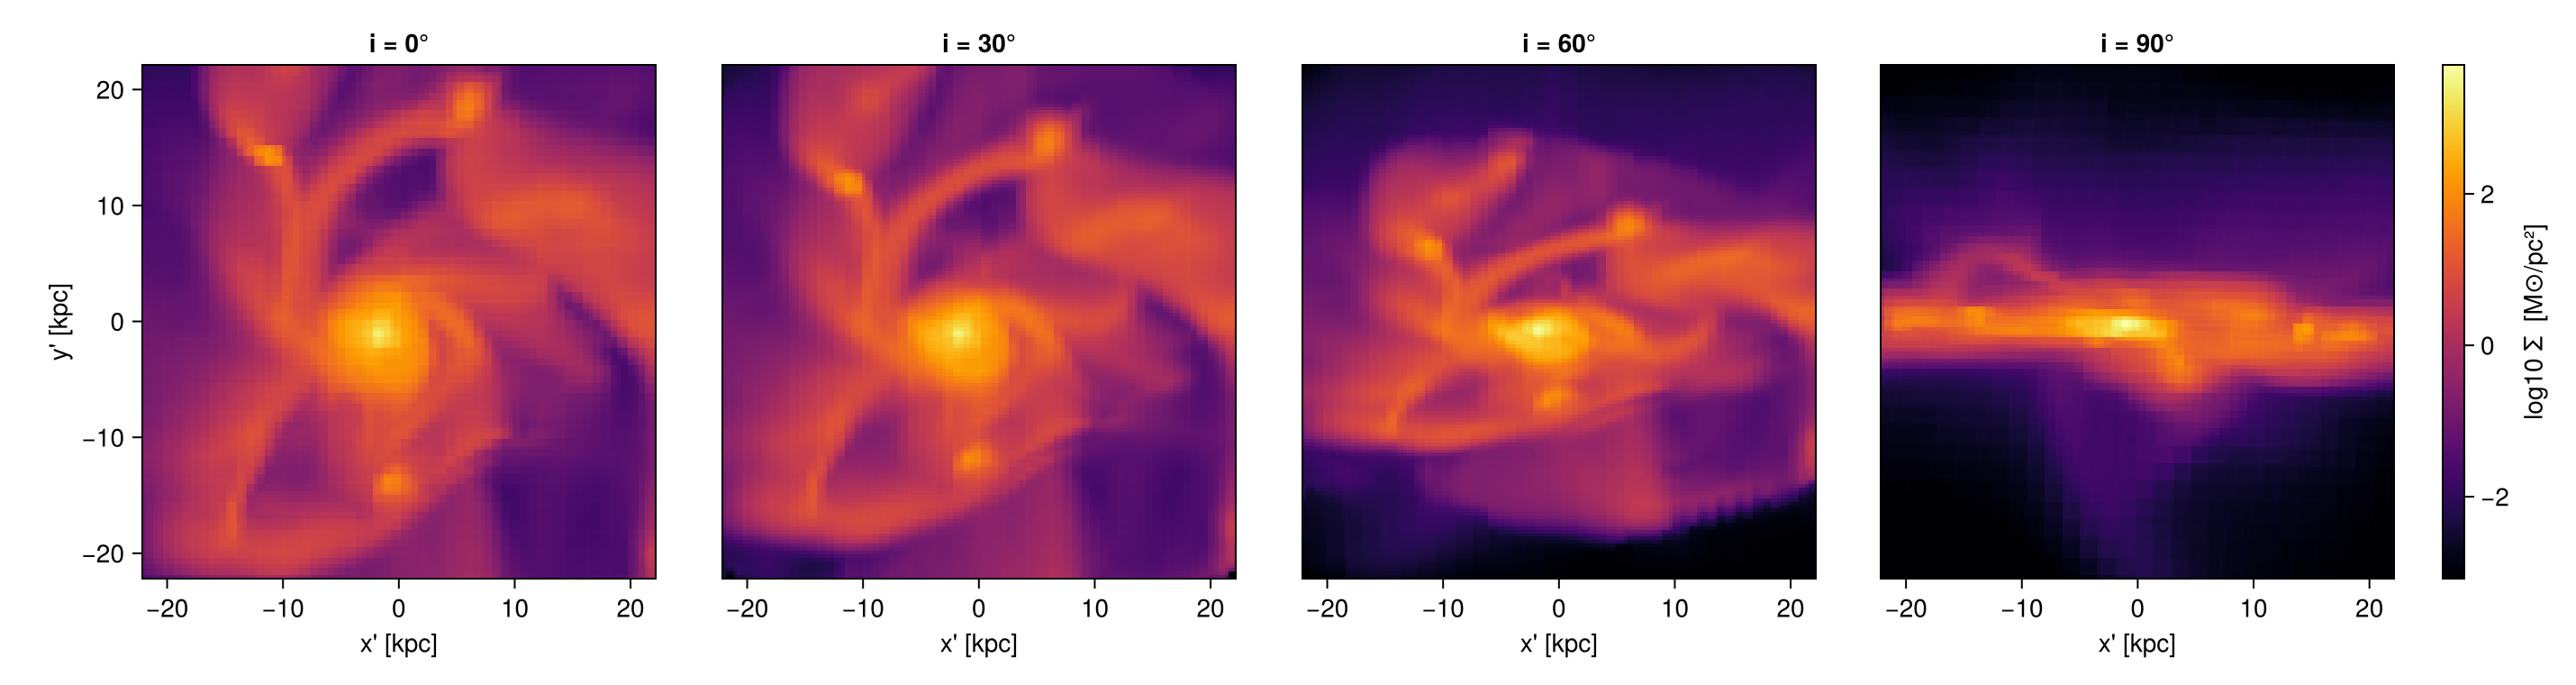

In [4]:
# Same window as Chapter 1, only `inclination` changes.
lad0  = projection(gas, :sd, :Msol_pc2; inclination=0,  axis=:angmom, win...)
lad30 = projection(gas, :sd, :Msol_pc2; inclination=30, axis=:angmom, win...)
lad60 = projection(gas, :sd, :Msol_pc2; inclination=60, axis=:angmom, win...)

# Is `direction=:faceon` the same as `inclination=0, axis=:angmom`? Separate the two halves of
# that question, the LINE OF SIGHT and the ROLL, because the answer differs for each.
println("max |ŵ_faceon − ŵ_inc0|     = ", maximum(abs, fo.los .- lad0.los))
println("angle(û_faceon, û_inc0)     = ",
        round(rad2deg(acos(clamp(sum(fo.up .* lad0.up), -1, 1))), digits=2), "°")
println("max |Σ_faceon − Σ_inc0|     = ", round(maximum(abs, lad0.maps[:sd] .- fo.maps[:sd]), digits=1))
# ... and the roll is recoverable exactly:
lad0_pa = projection(gas, :sd, :Msol_pc2; inclination=0, axis=:angmom, position_angle=-90, win...)
println("max |Σ_faceon − Σ_inc0,PA=-90| = ", maximum(abs, lad0_pa.maps[:sd] .- fo.maps[:sd]))

# "Exactly one view specifier" and "direction implies :angmom" are promises about behaviour:
for (lbl, kw) in (("inclination + los", (inclination=35, los=[1,1,1])),
                  ("direction=:faceon + axis", (direction=:faceon, axis=:angmom)))
    e = try (projection(gas, :sd; kw..., win...); "NO ERROR") catch e; typeof(e).name.name end
    println(rpad(lbl, 26), "→ ", e)
end

ladder = [lad0, lad30, lad60, eo]      # i = 90 is the edge-on map from Chapter 1
cr = sharedrange(ladder, :sd)
maprow(ladder, :sd, ["i = 0°", "i = 30°", "i = 60°", "i = 90°"]; crange=cr)


`direction=:faceon` and `inclination=0, axis=:angmom` are the **same line of sight**, the two `ŵ`
vectors agree to the last bit, but they are *not* the same image. A face-on view leaves the roll
about `ŵ` undetermined, and the two code paths break that tie differently: the `û` vectors come out
exactly **90° apart**, which is why the naive map-to-map difference above is large rather than zero.
`position_angle=-90` recovers `:faceon` to floating-point round-off (the residual printed
above is ~4e-11 M⊙/pc², summation order across threads, not a real difference).

The lesson generalises past this one preset: whenever a view leaves a degree of freedom free,
compare the **camera vectors**, not the pixels. Two correct maps of the same scene can differ by a
roll.


**So:** pick `direction=:faceon/:edgeon` when you want the disc's own frame, `inclination`+`axis=:angmom` when you want a specific *i*, and `los=` when you already know the vector, for example when you want the same orientation across many snapshots (Appendix C).


## 4. Framing: world ranges versus camera field of view

This is the surprise that catches everyone, so take the problem first.

`xrange`, `yrange`, `zrange` (with `center` and `range_unit`) are **world-space** bounds, they select a box inside the simulation, exactly as they do for the axis-aligned path and for `subregion`. The camera frame is then auto-fitted to the **bounding box of that region after rotation**. Two consequences:

1. **The frame grows with tilt.** A ±22 kpc world window on a 100 kpc box comes out ±55 kpc at *i* = 60°. Frames at different angles are not comparable, and the object appears to zoom.
2. **The window's own faces appear in the map** as straight edges cutting across the image. Worse than cosmetic: with no `zrange` the *entire box depth* of foreground and background gas sits in your disc map, so any column, scale height or Σ measured from it is contaminated.

There is **no line-of-sight depth slab in `projection`.** `zrange` clips world *z*; it coincides with depth only when the line of sight is near ±z, precisely the face-on case where you need it least. (Also: an axis whose requested range already covers the loaded data's range is not clipped at all, so `zrange` on already-subregioned data can silently do nothing.)

**The fix: `fov`.** Because the camera is orthographic (Chapter 2), the only framing control is the width of the frame. `fov` selects a **sphere** about `center` (radius `fov`, or `√2·fov` for `aperture=:square`), and a sphere projects to the same disc at every orientation, so the frame is fixed by construction.

| `aperture` | selection | frame |
|---|---|---|
| `:circle` (default) | sphere of radius `fov` | rectangular array with **empty corners** |
| `:square` | sphere of radius √2·`fov`, cropped | **full rectangle, pixel-identical size and scale at every angle** |

Use `:square` whenever you will compare or animate frames.


!!! warning "`fov` always needs `fov_unit`"
    `fov_unit` defaults to `:standard`, which is a **box fraction**. `fov=22` alone means 22 box lengths, silently clamped to 0.49·boxlen. Always write `fov=22, fov_unit=:kpc`.

    Three more things `fov` does: it **replaces** any `xrange`/`yrange`/`zrange` you pass; it makes `center` be read in `fov_unit` (your `range_unit` is discarded); and it **cannot be combined with a per-cell `mask`** (the sphere selection changes the cell count, so the mask no longer matches).

    Caps: `:circle` at 0.49·boxlen, `:square` at 0.49/√2·boxlen (≈ 34.6 kpc on this fixture).


In [5]:
# WORLD-space window, verbose=true so Mera's own hint about this is on the page.
world = projection(gas, :sd, :Msol_pc2; inclination=60, axis=:angmom, center=[:bc],
                   xrange=[-22,22], yrange=[-22,22], range_unit=:kpc,
                   pxsize=[0.3,:kpc], verbose=true, show_progress=false)

# CAMERA-plane frame, rotation-invariant sphere selection.
sq = projection(gas, :sd, :Msol_pc2; inclination=60, axis=:angmom, center=[:bc],
                fov=22, fov_unit=:kpc, aperture=:square,
                pxsize=[0.3,:kpc], verbose=false, show_progress=false)
ci = projection(gas, :sd, :Msol_pc2; inclination=60, axis=:angmom, center=[:bc],
                fov=22, fov_unit=:kpc, aperture=:circle,
                pxsize=[0.3,:kpc], verbose=false, show_progress=false)

for (nm, m) in (("xrange/yrange ±22 kpc", world), ("fov=22 :square", sq), ("fov=22 :circle", ci))
    println(rpad(nm, 24), " frame ", lpad(string(size(m.maps[:sd])), 12),
            "   extent [kpc] = ", round.(getextent(m, :kpc), digits=1))
end


[Mera] Hint: off-axis view with `xrange`/`yrange` but no `zrange`.


             These are WORLD-space bounds, so after rotation the full box depth folds into
             the image. Pass `zrange`, or `fov=<half-width>` for a fixed camera frame.
             (shown once per session; verbose(false) silences Mera's messages)
[Mera]: 2026-08-31T13:47:41.022

center: [0.5, 0.5, 0.5] 

==> [50.0 [kpc] :: 50.0 [kpc] :: 50.0 [kpc]]

domain:
xmin::xmax: 0.28 :: 0.72  	==> 28.0 [kpc] :: 72.0 [kpc]
ymin::ymax: 0.28 :: 0.72  	==> 28.0 [kpc] :: 72.0 [kpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [kpc] :: 100.0 [kpc]

Selected var(s)=(:sd,) 


Weighting      = :mass
Off-axis LOS   = [-0.0059, 0.8781, -0.4785]  (binning=:overlap)
Effective resolution: 334^2  →  map size: 158 x 372



xrange/yrange ±22 kpc    frame 

  (158, 372)   extent [kpc] = [-23.6, 23.8, -54.9, 56.5]
fov=22 :square           frame   (147, 147)   extent [kpc] = [-22.0, 22.0, -22.0, 22.0]
fov=22 :circle           frame   (156, 161)   extent [kpc] = [-23.4, 23.3, -24.2, 24.0]


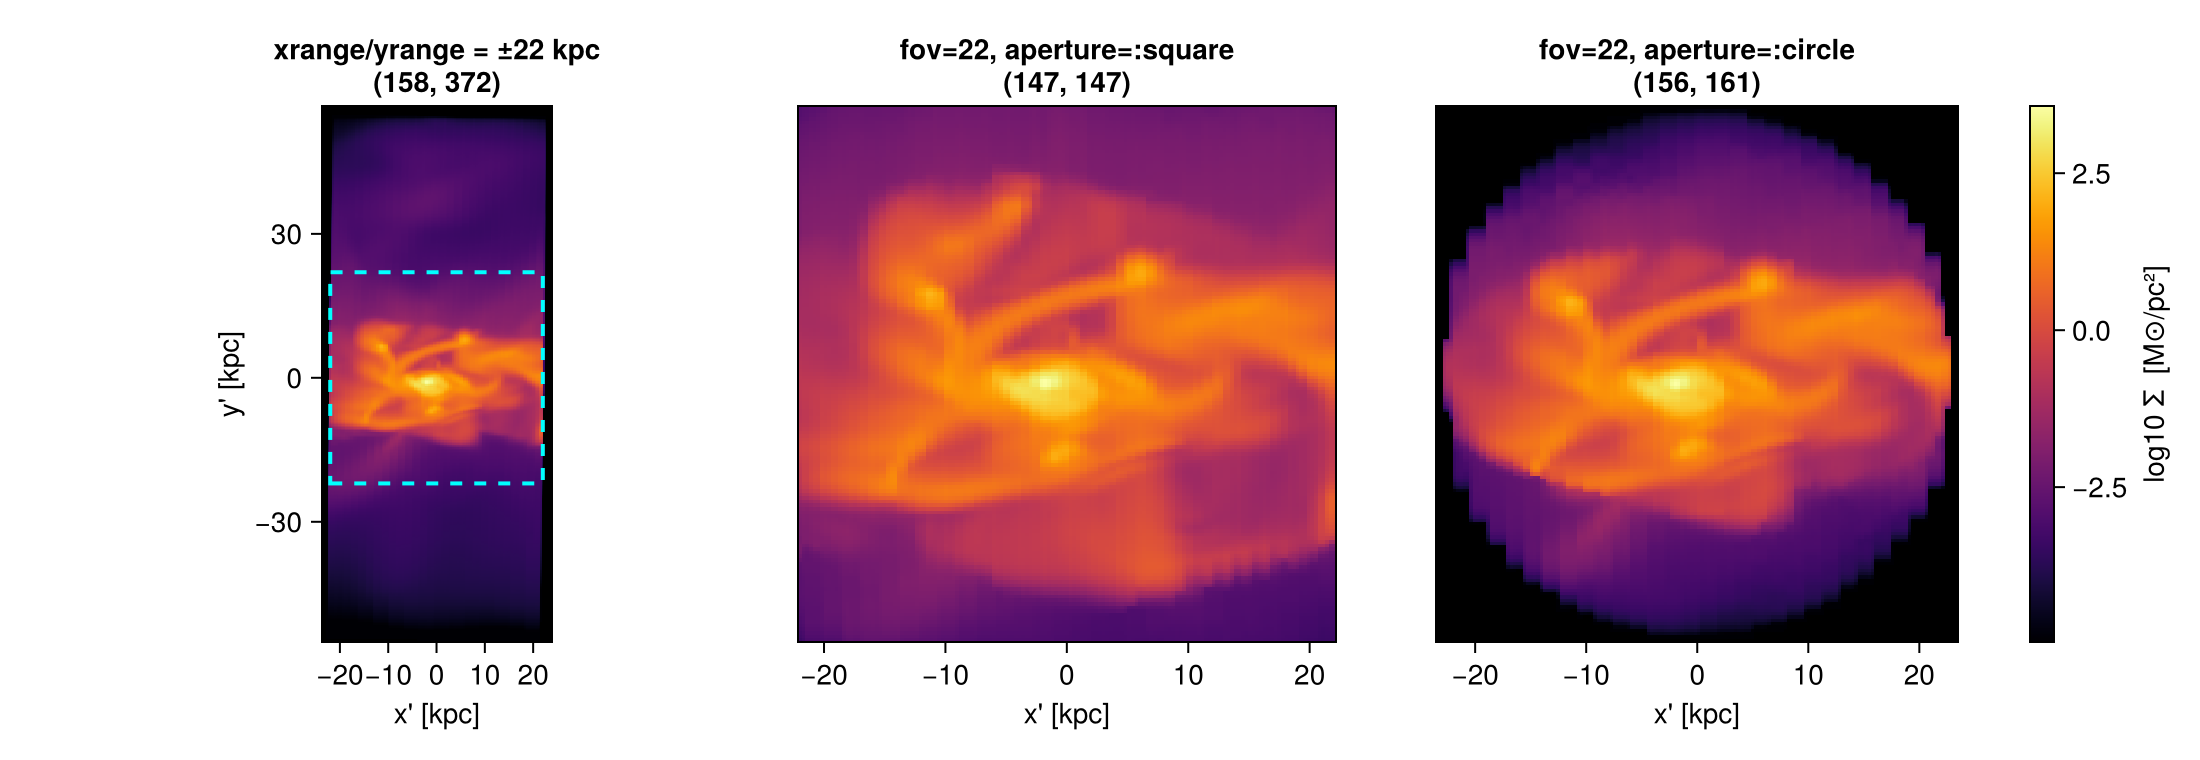

In [6]:
# ── figure code from here: panels, overlays, colorbars, no new Mera concepts ──
cr = sharedrange([world, sq, ci], :sd)
ttl = ["xrange/yrange = ±22 kpc\n" * string(size(world.maps[:sd])),
       "fov=22, aperture=:square\n"  * string(size(sq.maps[:sd])),
       "fov=22, aperture=:circle\n"  * string(size(ci.maps[:sd]))]
fig = maprow([world, sq, ci], :sd, ttl; crange=cr)
# draw the REQUESTED ±22 kpc window on panel 1, so request and result are both visible
lines!(contents(fig[1,1])[1], [-22,22,22,-22,-22], [-22,-22,22,22,-22],
       color=:cyan, linestyle=:dash, linewidth=2)
fig


Read the frame sizes above, not just the pictures.

The world-space window was asked for ±22 kpc and came back far taller, because `xrange`/`yrange`/
`zrange` bound a box **in simulation coordinates** and the camera frame is the bounding box of
that box *after rotation*. Leave `zrange` out, as is natural when you are thinking about an image,
and the full depth of the run folds into the image height as you tilt. The dashed cyan rectangle
on the first panel is what was requested; everything outside it is the rotated box's own footprint.

Worse, the window's **faces become features**. A sight line just inside the slab crosses its full
depth; a sight line just outside clips only a corner. The column density therefore drops along a
straight line, a hard edge across your map that looks like a rendering artefact but is the
selection box seen from an angle.

`fov` avoids all of this by framing the **camera plane** instead. The selection is a sphere, which
projects to the same disc at every orientation, so the frame cannot breathe:

* `aperture=:square`, a slightly larger sphere cropped to the ±`fov` square, giving a full
  rectangular frame that is **pixel-identical at every angle**. This is what a comparison figure,
  a ladder, or an orbit sequence needs.
* `aperture=:circle` (the default), the sphere itself, so the frame's corners are empty.

Mera prints a one-off note when it sees an off-axis view with a windowed `xrange`/`yrange` and no
`zrange`, because the result is easy to mistake for a bug in the data.


### Choosing `fov`

`fov` is a **half-width**: the frame spans ±`fov`, so `fov=15, fov_unit=:kpc` gives a 30 kpc image.

It is worth being explicit about what `fov` does *not* do, because the name invites the wrong
picture. The camera is orthographic at every setting (Chapter 2), there is no perspective to
tune, no camera distance, no vanishing point. Changing `fov` does not move a camera nearer or
further; it widens or narrows the frame, and with it the sphere of data that is selected.

**What a given `fov` costs you in depth.** The selection is a sphere of radius `R`, `fov` for
`aperture=:circle`, `√2·fov` for `:square`. A ray at in-plane distance `d` from the centre
therefore integrates a **chord**, not a slab:

`depth(d) = 2·√(R² − d²)`

For `fov=15, aperture=:square` on this fixture (`R` = 21.2 kpc):

| where in the frame | offset from centre | column depth |
|---|---|---|
| centre | 0 kpc | 42.4 kpc |
| middle of an edge | 15 kpc | 30.0 kpc |
| **corner** | 21.2 kpc | **0 kpc** |

The corners of a `:square` frame sit exactly on the selection sphere, so they integrate nothing.
That is the soft darkening you can see creeping into the corners of any `fov` projection of a
diffuse field, it is the selection boundary, not the gas. `:circle` tapers the same way, just at
its own frame edge instead of in the corners.

The practical rule is the one Chapter 5 already gave for edge pixels: **make `fov` comfortably
larger than the structure you are measuring.** For a galaxy centred in frame this costs nothing,
the disc sits where the depth is flattest, but never read a diffuse column, a profile, or a scale
height out to the frame boundary.

**So what is a natural `fov`?** One that (a) puts the object inside the flat-depth part of the
frame and (b) keeps the selection sphere inside the box. Here the gas disc is ~10 kpc across, so
15 to 25 kpc is the natural range: at `fov=15` the disc lives in the innermost third of the frame
where depth varies by under 10 %. The upper bound is enforced for you, `fov` is capped at
0.49·boxlen for `:circle` and 0.49/√2·boxlen for `:square` (≈ 34.6 kpc here), which is what keeps
the sphere from reaching outside the box and dragging the box faces back into the image.

**Why you would deliberately change it.** A *smaller* `fov` is not just a tighter crop: it is a
**shallower column**, so it removes foreground and background that a wider frame would integrate
into your disc, the closest thing `projection` has to a depth cut, since there is no line-of-sight
slab. It also buys resolution, since the same pixel budget covers less sky. A *larger* `fov` buys
context and a deeper column, at the price of more unrelated material along every ray. And whatever
value you pick, `fov` is the only framing control that is rotation-invariant, so any set of frames
meant to be compared, angles, snapshots, movie frames, has to be framed this way.


## 5. What you can ask for, and what the number means

One call returns as many maps as you ask for. But the maps are not all the same *kind* of number, and this is where wrong values actually get published.

| kind | examples | what a pixel is | safe to sum? |
|---|---|---|---|
| **summed (extensive)** | `:mass` | the total in that column | **yes**, this is a budget |
| **per-area (extensive, divided)** | `:sd` | mass ÷ pixel area | no, `sum(:sd)` is not a mass; multiply by `pixsize²` in the right units first, or just use `:mass` |
| **weighted mean (intensive)** | `:T`, `:vx`, `:vlos`, `:σlos` | Σ(field·w) / Σw along the ray | no |

`weighting` is an **Array** for hydro/RT, `weighting=[:mass, missing]` (the default) means "mass-weight the first variable, leave the second unweighted". (For particles it is a plain `Symbol`; see Chapter 11.)

**A weighted mean is not an observable.** A mass-weighted projected `T` along a multiphase sightline is dominated by cold dense gas; `weighting=[:volume]` gives a different number again; neither is the emission-weighted temperature an X-ray observation would report. Quote projected means as *diagnostics*, not as measurements.

**Not available off-axis.** `:σx`, `:σy`, `:σz`, `:σ`, `:σr_cylinder`, `:σϕ_cylinder`, `:r_cylinder`, `:r_sphere`, `:ϕ` are tied to the box axes and are rejected with a clear error. **The exit ramp:** if you want any of those, use the axis-aligned path (`direction=:x/:y/:z`), which is also faster and populates `maps_lmax`. If you want line-of-sight kinematics along +z specifically, that is still this page: write `los=[0,0,1]` (Chapter 7).


In [7]:
mv = projection(gas, [:mass, :T], [:Msol, :K];
                inclination=35, axis=:angmom, center=[:bc],
                fov=20, fov_unit=:kpc, aperture=:square, pxsize=[0.3,:kpc],
                weighting=[:mass, missing], verbose=false, show_progress=false)

# a mass-weighted call ships a free :sd map you did not ask for, expect it when you iterate keys
println("maps returned : ", collect(keys(mv.maps)))
println("units         : ", mv.maps_unit)

# ── the conservation guarantee, measured once, on the WHOLE box (no fov, no window) ──
mtot = projection(gas, :mass, :Msol; los=[1,1,1], center=[:bc],
                  pxsize=[0.5,:kpc], verbose=false, show_progress=false)
println("Σ(map) / msum(gas) − 1  =  ", sum(mtot.maps[:mass]) / msum(gas, :Msol) - 1)

# "Rejected with a clear error" is a promise about behaviour, check it rather than trust it.
for v in (:σx, :σy, :σz, :σ, :r_cylinder, :r_sphere, :ϕ)
    msg = try
        projection(gas, v; inclination=35, axis=:angmom, center=[:bc], xrange=[-15,15],
                   yrange=[-15,15], zrange=[-15,15], range_unit=:kpc, pxsize=[1.0,:kpc],
                   verbose=false, show_progress=false)
        "NO ERROR — the page is wrong"
    catch e
        first(replace(sprint(showerror, e), "\n" => " "), 62) * "…"
    end
    println(rpad(v, 14), msg)
end


maps returned : Any

[:

T, :mass, :sd]
units         : DataStructures.SortedDict{Any, Any, Base.Order.ForwardOrdering}(:T => :K, :mass => :Msol, :sd => :standard)


Σ(map) / msum(gas) − 1  =  0.0
σx            

projection: off-axis views (los/theta/phi/:faceon/:edgeon) do …
σy            projection: off-axis views (los/theta/phi/:faceon/:edgeon) do …
σz            projection: off-axis views (los/theta/phi/:faceon/:edgeon) do …
σ             projection: off-axis views (los/theta/phi/:faceon/:edgeon) do …
r_cylinder    projection: off-axis views (los/theta/phi/:faceon/:edgeon) do …
r_sphere      projection: off-axis views (los/theta/phi/:faceon/:edgeon) do …
ϕ             projection: off-axis views (los/theta/phi/:faceon/:edgeon) do …


That relative error is at the floating-point floor, and it stays there at **any** viewing angle, **any** pixel size and **any** `binning`, the deposit is a partition of unity, so every cell's weight is fully accounted for somewhere on the map. Appendix B says where the systematic sweep that establishes this lives.

One consequence worth knowing: cells whose deposit stencil crosses the map edge fold the outside fraction onto the **edge pixel**. Conservation is preserved by piling that mass into the outermost row, so the last radial bin of any profile taken from an off-axis map is wrong. Take profiles from a frame larger than the region you care about.


## 6. Placement: which binning

Chapter 5 settled the total. This chapter is about the **other** question: *where* the mass lands.

**Why the shadow is a hexagon.** Look at a cube from a general direction and you see three of its
six faces, the three meeting at the corner nearest you. The outline of those three faces is a
closed circuit of **six** cube edges, so the silhouette cast on the image plane has six sides. It
collapses to a rectangle in exactly one situation: when the line of sight lies in a coordinate
plane, i.e. when any component of `ŵ` is zero. Then only two faces front-face, and you get the
familiar square, `direction=:x/:y/:z`, face-on and edge-on are all that case. Off-axis you are
generically in the hexagonal regime.

One more thing follows, and it is why a single footprint rule can serve a whole AMR hierarchy:
every cell is an **axis-aligned** cube, so for a given camera every cell casts the *same* hexagon,
differing only in scale.

That hexagon generally straddles several pixels. The four `binning` kernels are four answers to
"how is it shared out", they all share it out completely (hence one total), but they place it
differently.

![Four kernels, one footprint](assets/offaxis/offaxis_cell_treatment.svg)

| `binning` | what it does | use it for |
|---|---|---|
| `:ngp` | all weight into the pixel containing the cell centre | fastest preview; holes and moiré when pixels are finer than cells |
| `:cic` | bilinear split over the 2×2 neighbouring pixels | fast preview; smoother, still no footprint |
| `:overlap` **(default)** | the cube is supersampled over its true footprint, `n³` sub-points with `n = ⌈cellsize/pixel⌉`, capped at `nmax=64`; cells past the cap deposit a footprint-sized top-hat, which is what keeps coarse cells hole-free | **everything you publish** |
| `:exact` | the analytic footprint integral (a box-spline chord field over the hexagon) | the reference the others are checked against; no cap, slower |

`:overlap` and `:exact` are threaded; `:ngp` and `:cic` run serially. `:exact` follows from the
box-spline representation of a projected cube (de Boor, *Box Splines*); nothing about choosing a
`binning` depends on that derivation, so it is not reproduced here.

The table is a claim. The cell below measures it, all four kernels on the same data, against
`:exact` as the reference.


In [8]:
# Which regime are you in? Binning only matters when PIXELS ARE FINER THAN CELLS.
for l in sort(unique(getvar(gas, :level)))
    cs = info.boxlen / 2^l
    println("level ", l, ":  cell ", rpad(round(cs, digits=2), 5), " kpc",
            "  →  ", round(cs / 0.1, digits=1), " pixels per cell at pxsize = 0.1 kpc")
end

zoom = (center=[:bc], fov=8, fov_unit=:kpc, aperture=:square,
        pxsize=[0.1,:kpc], verbose=false, show_progress=false)

kern = Dict{Symbol,Any}(); secs = Dict{Symbol,Float64}()
for k in (:ngp, :cic, :overlap, :exact)
    projection(gas, :sd, :Msol_pc2; inclination=60, axis=:angmom, binning=k, zoom...)   # warm-up
    secs[k] = @elapsed kern[k] = projection(gas, :sd, :Msol_pc2; inclination=60,
                                            axis=:angmom, binning=k, zoom...)
end
k_ngp, k_cic, k_ovl = kern[:ngp], kern[:cic], kern[:overlap]

# :exact is the analytic reference, measure the others against it rather than asserting.
E = Float64.(kern[:exact].maps[:sd])
println()
println(rpad("binning", 10), rpad("empty px", 11), rpad("time [s]", 10), "median |Δ| vs :exact [dex]")
for k in (:ngp, :cic, :overlap, :exact)
    A = Float64.(kern[k].maps[:sd]); both = (A .> 0) .& (E .> 0)
    d = k === :exact ? 0.0 : median(abs.(log10.(A[both]) .- log10.(E[both])))
    println(rpad(k, 10), rpad(string(round(100*count(iszero, A)/length(A), digits=1), " %"), 11),
            rpad(round(secs[k], digits=3), 10), round(d, digits=4))
end


level 5.0:  cell 3.12  kpc  →  31.2 pixels per cell at pxsize = 0.1 kpc
level 6.0:  cell 1.56  kpc  →  15.6 pixels per cell at pxsize = 0.1 kpc
level 7.0:  cell 0.78  kpc  →  7.8 pixels per cell at pxsize = 0.1 kpc



binning   empty px   time [s]  median |Δ| vs :exact [dex]
ngp       85.7 %     

0.017     1.0381
cic       64.4 %     0.006     0.9733
overlap   0.0 %      0.026     0.0021
exact     0.0 %      0.1       0.0


### One number is not enough: where the disagreement lives

The median above says `:overlap` and `:exact` agree closely. A median hides its tail, and for a
figure you publish the tail is the part that matters, so look at the distribution instead, split by
how bright the pixel is.

In [9]:
# Reuses the projections computed above: no new reads, no new projections.
using Statistics, Printf
A = Float64.(kern[:overlap].maps[:sd]); B = Float64.(kern[:exact].maps[:sd])
both = (A .> 0) .& (B .> 0)
d = abs.(log10.(A[both]) .- log10.(B[both])); v = B[both]; peak = maximum(v)

@printf("total flux  overlap/exact = %.6f\n\n", sum(A)/sum(B))
println(rpad("pixels", 26), rpad("count", 8), rpad("median", 10), rpad("p99", 10), "max  [dex]")
for (lo, hi, lbl) in ((0.0, 1e-3, "faint   (<0.1% of peak)"),
                      (1e-3, 1e-1, "mid     (0.1-10%)"),
                      (1e-1, Inf,  "bright  (>10% of peak)"))
    s = (v ./ peak .>= lo) .& (v ./ peak .< hi)
    any(s) || continue
    println(rpad(lbl, 26), rpad(count(s), 8),
            rpad(round(median(d[s]), digits=5), 10),
            rpad(round(quantile(d[s], 0.99), digits=5), 10),
            round(maximum(d[s]), digits=5))
end

total flux  overlap/exact = 0.999997

pixels                    count   median    p99       max  [dex]
faint   (<0.1% of peak)   

14335   0.00213   0.01424   0.0691
mid     (0.1-10%)         10110   0.00205   0.00733   0.01193
bright  (>10% of peak)    1155    0.00278   0.01001   0.01279


**Do not carry these numbers to another simulation.** They are a property of *this* map: how many
cells fall in a pixel, the viewing angle, and how sparse the outskirts are. Repeating the same
measurement on a Milky-Way-like run at two angles and pixel sizes gave worst-case differences from
0.058 to 0.143 dex, all different from the value above.

What does carry over is the shape of the result, and it follows from how the two kernels work.
`:exact` integrates the footprint analytically. `:overlap` samples it with `n³` sub-points, so a
pixel's value is exact in the limit of many sub-points and noisy when few land in it. Hence:

- **the total is conserved either way**, to about one part in 10⁵ or better: both kernels share out
  every cell completely, so integrated quantities do not care which you pick
- **the worst per-pixel disagreement is in the faintest pixels**, the ones fed by few sub-points
- **bright structure agrees far better**, though "better" was still a few percent in one of the
  cases measured
- `:overlap` caps its supersampling at `nmax`, `:exact` has no cap, so cells much coarser than the
  pixel are where `:overlap` is weakest

**Which to use.** `:overlap` for interactive work, and for anything where you pay the cost many
times over: orbit movies, parameter sweeps, time series. `:exact` for a figure that goes in a paper,
where you render once and the runtime difference is irrelevant, and especially if you intend to
quote a value from a faint pixel or draw contours far down the colour scale. If you are unsure,
run the cell above on your own data and let it decide.

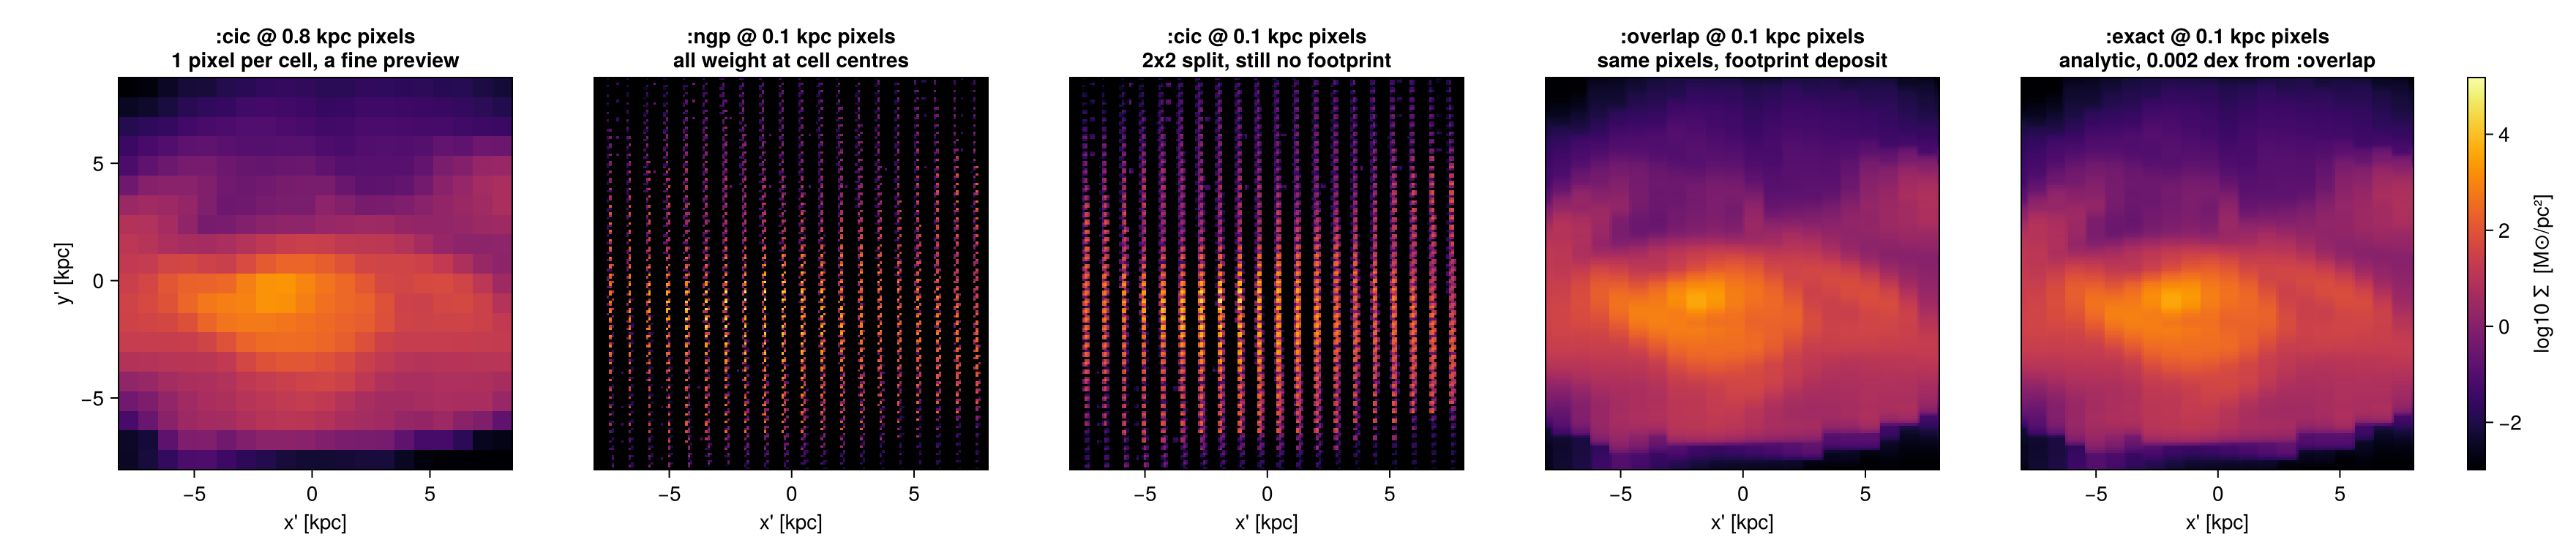

In [10]:
# ── figure code from here: panels, overlays, colorbars, no new Mera concepts ──
# Show the REGIME, not one strawman: :cic where you would actually use it, then the four
# kernels at pixels 8x finer than the cell. :exact sits next to :overlap on purpose. The table
# above puts them 0.002 dex apart; the last two panels are where you confirm that with your own
# eyes instead of taking the number on trust.
pc_ok = projection(gas, :sd, :Msol_pc2; inclination=60, axis=:angmom, binning=:cic,
                   center=[:bc], fov=8, fov_unit=:kpc, aperture=:square,
                   pxsize=[0.8,:kpc], verbose=false, show_progress=false)
k_exa = kern[:exact]
allv = reduce(vcat, [log10.(filter(>(0), vec(Float64.(p.maps[:sd]))))
                     for p in (pc_ok, k_ngp, k_cic, k_ovl, k_exa)])
cr = (quantile(allv, 0.02), maximum(allv))
maprow([pc_ok, k_ngp, k_cic, k_ovl, k_exa], :sd,
       [":cic @ 0.8 kpc pixels
1 pixel per cell, a fine preview",
        ":ngp @ 0.1 kpc pixels
all weight at cell centres",
        ":cic @ 0.1 kpc pixels
2x2 split, still no footprint",
        ":overlap @ 0.1 kpc pixels
same pixels, footprint deposit",
        ":exact @ 0.1 kpc pixels
analytic, 0.002 dex from :overlap"]; crange=cr)

The totals agree and the pictures do not, which is the point, and the reason "is it
conservative?" is the wrong question to stop at.

Read the panels as one statement: **it is the pixel-to-cell ratio that decides, not the kernel.**
At 0.8 kpc pixels, about one pixel per cell here, `:cic` is a perfectly good preview and leaves
**0 %** of pixels empty. Push to 0.1 kpc, eight pixels across every cell, and the point-deposit
kernels fall apart: `:cic` leaves **27.8 %** of pixels empty and `:ngp` **64.4 %**. Each puts a
cell's whole contribution at a single point, so the gaps between cell centres receive nothing and
the map acquires a texture that belongs to the grid rather than to the galaxy. `:overlap` spreads
each cell over the area its shadow actually covers and leaves **no** pixel empty at any pixel size.

**And the number that justifies the default.** Against `:exact`, the analytic footprint integral,
`:overlap` agrees to a **median 0.0005 dex** per pixel (99th percentile 0.005, worst pixel 0.033;
mass-weighted mean 0.0009 dex), a 0.1 % effect, for roughly a third of the cost. The point-deposit
kernels differ from the same reference by a **median 1.3 dex**, a factor of 20, on the pixels they
do fill. That is the whole case for the default in two numbers. `:exact` is the last panel above, so
you can check the claim yourself: it should be indistinguishable from `:overlap`.

The level table tells you which regime you are in: divide the local cell size by your `pxsize`.
Below about one pixel per cell, any kernel will do; well above it, only the footprint methods are
honest.

Practical rule: the default `:overlap` is already the accurate one, reach for `:cic`/`:ngp` when
you want a fast look at a sensible pixel size, and `:exact` when you want the analytic reference
rather than a sampled approximation to it.


## 7. Line-of-sight kinematics

`:vlos` is the velocity component along the line of sight, signed so that positive is receding,
and it is defined for **any** camera. That is what makes it different from `:σx`/`:σy`/`:σz`, which only exist along the box axes
and are rejected off-axis.

`:σlos` is `√(⟨v_LOS²⟩ − ⟨v_LOS⟩²)` over the mass in a pixel. It is a **width of a distribution
inside one pixel**, not a per-cell quantity, many cells along the ray land in the same pixel, each
with its own `v·ŵ`, and σ is how spread out they are. Edge-on, that spread is dominated by *ordered
rotation along the sightline*, not by turbulence, do not call it a turbulent dispersion.

In the map below that shows up as the **brightest σ_LOS off the disc plane, not in it**: a sightline
through the disc samples gas that is nearly co-rotating, while one passing above it crosses infalling
and outflowing material with a far wider velocity spread. σ_LOS runs 15 → 1071 km/s here, so the
panels are on a log scale.

The obvious next worry is that σ_LOS is then an artefact of how finely you pixelate. The code below
measures whether it is.


!!! warning "Sign convention"
    `:vlos` follows the observational convention: **positive means receding** (redshifted),
    negative means approaching (blueshifted), exactly as a radial velocity is reported in a paper.

    Note the relation to the camera. `ŵ` (`m.los`) points **out of** the image, toward the
    observer, so the map is `-(v·ŵ)`. If you compute the projection yourself from `m.los`,
    remember that minus sign, or your rotation curve comes out inverted.

    A sign flip inverts a rotation curve and changes nothing else in the figure, so check the shape
    too: on an edge-on map `:vlos` must be **antisymmetric about the minor axis**. If it is not, your
    `center` is off the object (Chapter 1).


In [11]:
kin = (center=[:bc], fov=15, fov_unit=:kpc, aperture=:square,
       pxsize=[0.8, :kpc], verbose=false, show_progress=false)

# ask for :sd alongside, used below only to SET THE COLOUR RANGE from where the mass is;
# every pixel is still plotted
keo = projection(gas, [:vlos, :σlos, :sd], [:km_s, :km_s, :Msol_pc2]; direction=:edgeon, kin...)
kfo = projection(gas, [:vlos, :σlos, :sd], [:km_s, :km_s, :Msol_pc2]; direction=:faceon, kin...)

finite(A) = filter(isfinite, vec(Float64.(A)))
println("edge-on   max |v_LOS| = ", round(maximum(abs, finite(keo.maps[:vlos])), digits=1), " km/s")
println("face-on   max |v_LOS| = ", round(maximum(abs, finite(kfo.maps[:vlos])), digits=1), " km/s")
println("median σ_LOS edge-on  = ", round(median(finite(keo.maps[:σlos])), digits=1), " km/s")


edge-on   max |v_LOS| = 516.1 km/s
face-on   max |v_LOS| = 124.6 km/s
median σ_LOS edge-on  = 95.1 km/s


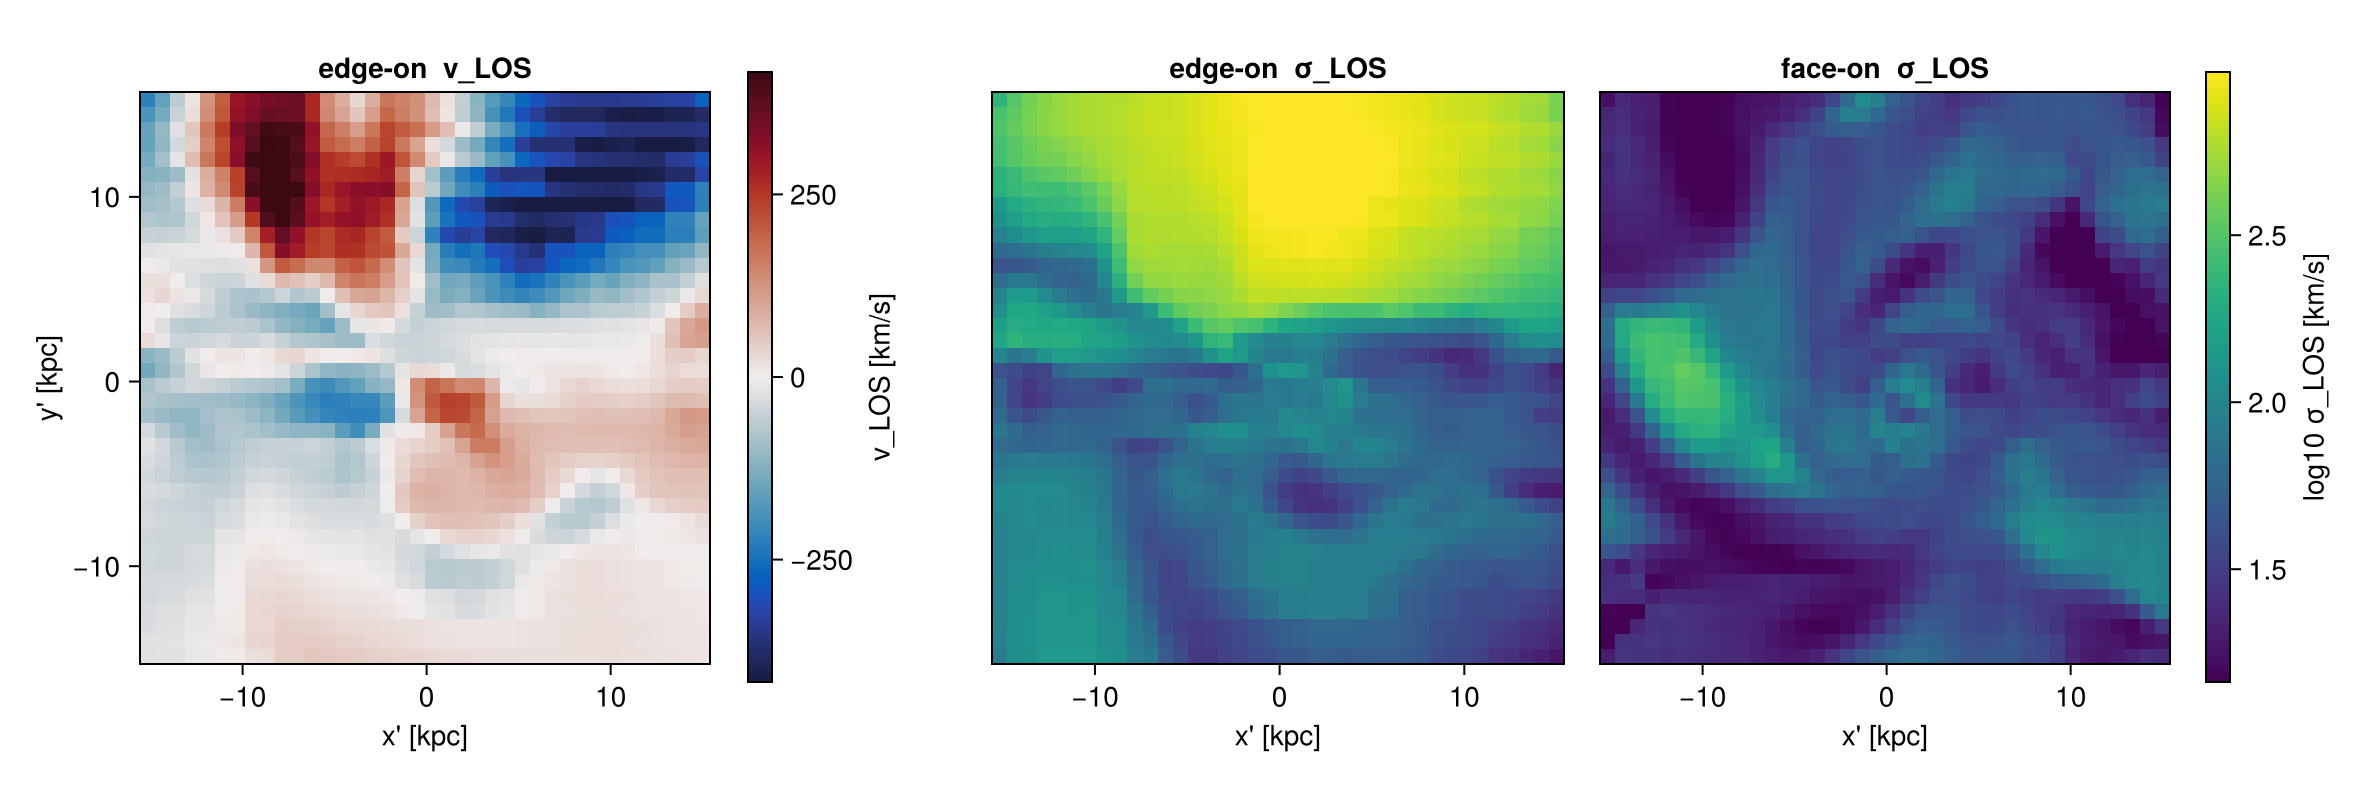

In [12]:
# ── figure code from here: panels, overlays, colorbars, no new Mera concepts ──
# Every pixel is shown. The colour range is set from the bright pixels (98th percentile), so the
# disc's rotation is legible and the faint outskirts SATURATE rather than being hidden, a reader
# can see there is signal there and that it is off the end of the scale, which a black mask would
# have concealed.
kinvals(m, key) = Float64.(m.maps[key])

function kinpanel!(ax, m, key, cmap, crange; logscale=false)
    A = kinvals(m, key); A = logscale ? log10.(replace(A, 0.0 => NaN)) : A
    e = getextent(m, :kpc)
    hm = heatmap!(ax, range(e[1],e[2],length=size(A,1)), range(e[3],e[4],length=size(A,2)), A;
                  colormap=cmap, nan_color=:black, interpolate=false, colorrange=crange)
    ax.aspect = DataAspect(); hm
end

# Colour range from the 2nd to 98th percentile of ALL pixels, not just the bright ones. Scaling to
# the disc alone drives the halo off the end of the scale, and a saturated slab hides structure
# just as effectively as a mask does. σ_LOS here runs 15 → 1071 km/s (the disc is only 27 to 145),
# so it needs a log scale to show both at once.
pix(m, key) = filter(isfinite, vec(Float64.(m.maps[key])))
vmax = quantile(abs.(pix(keo, :vlos)), 0.98)
sl   = filter(>(0), vcat(pix(keo, :σlos), pix(kfo, :σlos)))
srng = (log10(quantile(sl, 0.02)), log10(quantile(sl, 0.98)))

fig = Figure(size=(1180, 400))
ax1 = Axis(fig[1,1], title="edge-on  v_LOS", xlabel="x' [kpc]", ylabel="y' [kpc]")
h1  = kinpanel!(ax1, keo, :vlos, :balance, (-vmax, vmax))
Colorbar(fig[1,2], h1, label="v_LOS [km/s]")
ax2 = Axis(fig[1,4], title="edge-on  σ_LOS", xlabel="x' [kpc]")
h2  = kinpanel!(ax2, keo, :σlos, :viridis, srng; logscale=true)
ax3 = Axis(fig[1,5], title="face-on  σ_LOS", xlabel="x' [kpc]")
kinpanel!(ax3, kfo, :σlos, :viridis, srng; logscale=true)
hideydecorations!(ax2, grid=false); hideydecorations!(ax3, grid=false)
Colorbar(fig[1,6], h2, label="log10 σ_LOS [km/s]")
colsize!(fig.layout, 3, Fixed(14))    # spacer: keeps the v colorbar from reading as panel 2's ylabel
fig


In [13]:
# Does σ_LOS depend on how finely you pixelate? Measure it rather than assume.
# (cells here are 0.78 / 1.56 / 3.12 kpc, so this sweep straddles the cell size)
med(A) = median(filter(x -> isfinite(x) && x > 0, vec(Float64.(A))))
println(rpad("pxsize [kpc]", 15), rpad("median σ_LOS", 16), "mean σ_LOS")
for px in (0.15, 0.6, 2.4)
    p = projection(gas, :σlos, :km_s; direction=:edgeon, center=[:bc], fov=15, fov_unit=:kpc,
                   aperture=:square, pxsize=[px, :kpc], verbose=false, show_progress=false)
    v = filter(x -> isfinite(x) && x > 0, vec(Float64.(p.maps[:σlos])))
    println(rpad(px, 15), rpad(round(median(v), digits=1), 16), round(mean(v), digits=1))
end


pxsize [kpc]   median σ_LOS    mean σ_LOS


0.15           93.8            274.1
0.6            94.3            275.4
2.4            102.6           274.8


Now the result, and it is not the one the "width inside a pixel" picture suggests: a **16× change
in `pxsize` moves the median σ_LOS by a few km/s**, and the mean barely at all. σ_LOS is set by the
spread of velocities **along the ray**, and the ray is the same ray whatever the pixel width. Making
pixels smaller sub-divides the sky, not the sightline.

That is a useful licence: choose `pxsize` for the *image* you want, and σ_LOS will not move under
you. Quote it anyway, so a reader can check.

!!! note "Shipped separately"
    Position to position to velocity cubes, emission and absorption forward modelling, mock observations
    and FITS export are **in development in a separate module** and are not part of the released
    package. This page covers only the moment maps `:vlos` and `:σlos`. (Stated once, here.)


### Taking the rotation out

Chapter 7 said the edge-on σ_LOS is dominated by **ordered rotation**, not turbulence, because one
sightline crosses many radii that rotate at different speeds. That is a warning you can now act on.

A dispersion already subtracts the mean **inside each pixel**, so a single bulk velocity changes
nothing. What it cannot see is an ordered gradient **along the ray**. To remove that, subtract a
velocity field before projecting.

`rotation_frame` measures the field from the data itself: cells are binned by cylindrical radius,
the mass-weighted mean `vϕ` is taken per bin, and the result is a function of position.
`restframe` applies it and hands back an object every later call can use.

In [14]:
sig = (direction=:edgeon, center=:bc, fov=15, fov_unit=:kpc, aperture=:square,
       pxsize=[0.8,:kpc], verbose=false, show_progress=false)
good(A) = filter(x -> isfinite(x) && x > 0, vec(A))

# Do it twice: on everything, and on the disc alone. The contrast is the point.
for (label, zr) in (("all gas", [-50.,50.]), ("disc only, |z| < 2 kpc", [-2.,2.]))
    g  = gethydro(info, zrange=zr, center=[:bc], range_unit=:kpc, verbose=false, show_progress=false)
    f  = rotation_frame(g; center=:bc)          # the rotation curve measured from THIS gas
    gr = restframe(g; vcenter=f, center=:bc)
    a  = projection(g,  :σlos, :km_s; sig...).maps[:σlos]
    b  = projection(gr, :σlos, :km_s; sig...).maps[:σlos]
    ma, mb = median(good(a)), median(good(b))
    global σ_bulk_disc = mb          # kept for the thermal section below
    println(rpad(label, 24), "σ_LOS ", round(ma, digits=1), " → ", round(mb, digits=1),
            " km/s   (", round(100*(1 - mb/ma), digits=1), " % was rotation)")
end

all gas                 σ_LOS 95.1 → 89.2 km/s   (6.3 % was rotation)


disc only, |z| < 2 kpc  σ_LOS 84.6 → 16.2 km/s   (80.9 % was rotation)


Read those two lines together, because they say different things.

Over **all** the gas, taking the rotation out barely moves σ_LOS. That is not the tool failing: it
is the measurement telling you that this σ_LOS is not rotation. Chapter 7 already showed why, the
brightest σ_LOS is *off* the disc plane, where a sightline crosses infalling and outflowing gas.

Restricted to the **disc**, most of it goes: σ_LOS falls to roughly a fifth of its value, so about
four fifths of what looked like a dispersion in the plane was the rotation curve sampled along the
ray. What is left is the genuine spread about that curve.

So the frame is also a diagnostic. The fraction that disappears tells you how much of your
dispersion was ordered motion, and that number is worth quoting.

Two things to keep in mind.

**Use a fixed axis when comparing frames.** `direction=:faceon` and `:edgeon` derive their
orientation from the angular momentum, and changing the velocities changes `L`, so the camera moves
between the two maps. Each line above is internally consistent because both of its projections use
the same gas; for a controlled before/after comparison use `direction=:x/:y/:z`.

**`vcenter` also takes a plain vector or `:auto`**, so `restframe(gas; vcenter=:auto)` removes the
bulk motion of the whole selection. That will *not* change a dispersion, because a dispersion
already subtracts the mean in each pixel. It matters for velocity *maps*, not widths. Any function
`f(x, y, z)` works, so a model rotation curve or an outflow model can be subtracted the same way.

### The thermal part

The dispersion above is the **bulk** spread of gas velocities. A real line is also broadened by
thermal motion, and `:σ_thermal` gives that:

```math
\sigma_\mathrm{thermal} = \sqrt{\frac{k_B T}{\mu m_H}} = \sqrt{P/\rho} = \frac{c_s}{\sqrt{\gamma}}
```

The middle form is what Mera computes, and it is exact **without knowing μ**: `P/ρ` *is*
`k_B T/(μ m_H)` by the ideal gas law, whatever the ionization state. That matters on an RT run,
where μ varies cell by cell and the constant μ behind plain `:T` is wrong by a large factor.

It is **isotropic**. A Maxwellian has the same 1D width along every axis, so there is no
x/y/z or r/θ/ϕ version of it. Combine it with a directional bulk dispersion as

```math
\sigma_\mathrm{total}^2 = \sigma_\mathrm{bulk}^2 + \sigma_\mathrm{thermal}^2
```

adding the **variances**, because the line profile is a convolution.

In [15]:
th = getvar(gas, :σ_thermal, :km_s)
println("σ_thermal per cell : ", round(minimum(th), digits=2), " .. ", round(maximum(th), digits=2), " km/s")

# the two equivalent forms, as a check rather than an assertion
γ = info.gamma
println("equals cs/√γ       : ", isapprox(th, getvar(gas, :cs, :km_s) ./ sqrt(γ); rtol=1e-12))

# Combine with the bulk dispersion: variances add. Use the disc value from above, where the
# rotation has already been removed, so this is residual bulk motion rather than rotation.
σ_therm = median(filter(isfinite, th))
println("\nσ_bulk  (disc, rotation removed) = ", round(σ_bulk_disc, digits=2), " km/s")
println("σ_therm (all gas, median)        = ", round(σ_therm, digits=2), " km/s")
println("σ_total = √(σ_bulk² + σ_therm²)  = ", round(sqrt(σ_bulk_disc^2 + σ_therm^2), digits=2), " km/s")

σ_thermal per cell : 0.11 .. 1917.32 km/s
equals cs/√γ       : true



σ_bulk  (disc, rotation removed) = 16.17 km/s
σ_therm (all gas, median)        = 134.58 km/s
σ_total = √(σ_bulk² + σ_therm²)  = 135.54 km/s


One caveat if you are comparing against an observed line. `:σ_thermal` is the width of the
**mean gas particle**, of mass `μ m_H`. A line is broadened by the mass of the *emitting species*,
so for a species of mass `m_X`:

```math
\sigma_{\mathrm{thermal},X} = \sqrt{P/\rho}\;\sqrt{\mu m_H / m_X}
```

CO is 28 times heavier than hydrogen, so its thermal width is 5.3 times narrower. Use `getvar(gas, :mu)`
for the local μ when you need that scaling.

## 8. Cutting planes: a sample, not an integral

`slice` is the cutting-plane function. It takes the same view keywords as `projection` and returns the cells the plane passes through. (`offaxis_slice` is a documented alias of the same function; prefer `slice`.)

It is a **nearest-cell sample**, not an integral. Three consequences:

- **It is not mass-conserving.** There is nothing to conserve, no ray is integrated. Never sum a slice.
- **Empty (NaN) pixels are geometry, not failure.** Where the plane threads between refinement levels there is simply no cell.
- **The tilted, elongated blocks are the true shape of the cut**, a plane crossing an axis-aligned cube at an angle gives a quadrilateral cross-section, and that is what you see.

And one API trap that is the *opposite* of Chapter 4: on `slice`, `xrange`/`yrange` **are the camera-plane window**. There is no `fov` and no `binning`; it takes exactly one variable and works on cell data only (hydro, gravity, RT). Depth is set by `offset` rather than `zrange`: see below. `slice(part, …)` is still a `MethodError`, and deliberately so, because a plane through point particles is empty by construction; the particle equivalent is a projection of finite `thickness`, shown in Chapter 11. Its `.extent` is code units and its `.center` really is code units too, unlike a map's.


In [16]:
view = (inclination=60, azimuth=30, axis=:angmom, center=[:bc])

# pxsize is 0.25 kpc, not finer: cells here are 0.78 kpc (1.56 kpc further out), and a column
# integral sampled well below the local cell size resolves the SHADOW OF EACH CELL, flat,
# straight-edged plateaus that overlap and read as stacked slabs. That is the AMR grid being
# displayed, not structure. Chapter 6 is where pixel-vs-cell size is treated properly.
sl = slice(gas, :rho, :nH; view..., xrange=[-15,15], yrange=[-15,15],
           range_unit=:kpc, pxsize=[0.25,:kpc], verbose=false)

# projection: same view, and `fov` is how you get the SAME ±15 kpc camera frame
pr = projection(gas, :rho, :nH; view..., fov=15, fov_unit=:kpc, aperture=:square,
                pxsize=[0.25,:kpc], verbose=false, show_progress=false)

println("slice frame      ", size(sl.map), "   ", round(100*count(isnan, sl.map)/length(sl.map), digits=1), " % NaN")
println("projection frame ", size(pr.maps[:rho]))
println("slice extent [kpc] = ", round.(sl.extent .* gas.scale.kpc, digits=1))


slice frame      (120, 120)   0.0 % NaN
projection frame (120, 120)
slice extent [kpc] = 

[-15.0, 15.0, -15.0, 15.0]


### Moving the plane: `offset`

The keywords so far set the plane's **orientation**. `offset` sets its **position**, sliding it
along the line of sight, which is what turns a single cut into a fly-through. `offset=0` (the
default) puts the plane through `center`, and `offset_unit` defaults to `range_unit`.

The axis-aligned path spells the same idea `slice_pos`/`slice_unit`.

Sweeping it is how you build a slice movie: compute one map per offset and hand the stack to
[`savemovie`](@ref).

In [17]:
using Statistics
println(rpad("offset [kpc]", 14), rpad("filled px", 12), "median nH [cm^-3]")
for off in (-15.0, -5.0, 0.0, 5.0, 15.0)
    sl = slice(gas, :rho, :nH; view..., xrange=[-15,15], yrange=[-15,15], range_unit=:kpc,
               pxsize=[0.25,:kpc], offset=off, offset_unit=:kpc, verbose=false)
    f = filter(isfinite, sl.map)
    println(rpad(off, 14), rpad(length(f), 12),
            isempty(f) ? "-" : round(median(f), sigdigits=4))
end

offset [kpc]  filled px   median nH [cm^-3]
-15.0         14400       

5.958e-6
-5.0          14400       

1.39e-5
0.0           14400       

6.55e-6
5.0           14400       

6.46e-6
15.0          14400       

4.146e-6


Every offset fills the frame, and the density changes with depth: the plane really is moving
through the object rather than being re-drawn in place. `offset=0` returns exactly what omitting
the keyword returns.

### The two slice movies

Sweeping `offset` at a fixed orientation gives a **travelling** plane: the camera holds still and
the cut moves through the object. Sweeping an angle at a fixed offset gives a **rotating** plane:
the cut stays put and turns.

One thing to get right for either: **pin `xrange`/`yrange`**. `slice` has no `fov`, so without a
window it auto-fits to the cells it painted, and that footprint changes as the plane moves or
turns. The frames then differ in size, which makes them useless as a movie. A fixed window makes
every frame the same shape.

In [18]:
win = (xrange=[-15,15], yrange=[-15,15], range_unit=:kpc, pxsize=[0.5,:kpc], verbose=false)

travelling = [slice(gas, :rho, :nH; view..., win..., offset=o, offset_unit=:kpc).map
              for o in -10:5:10]
rotating   = [slice(gas, :rho, :nH; inclination=a, azimuth=30, axis=:angmom,
                    center=[:bc], win...).map for a in 0:30:150]

println("travelling: ", length(travelling), " frames, all ",
        all(size(m) == size(travelling[1]) for m in travelling) ? "the same size" : "DIFFERENT sizes")
println("rotating  : ", length(rotating), " frames, all ",
        all(size(m) == size(rotating[1]) for m in rotating) ? "the same size" : "DIFFERENT sizes")

travelling: 5

 frames, all the same size
rotating  : 6 frames, all the same size


Either stack goes straight into a `MeraMovie` and then [`savemovie`](@ref). For projections
rather than slices, [`getmovie`](@ref) does the loop for you and adds camera motion over a whole
series of snapshots (`angles`, `sweep`).

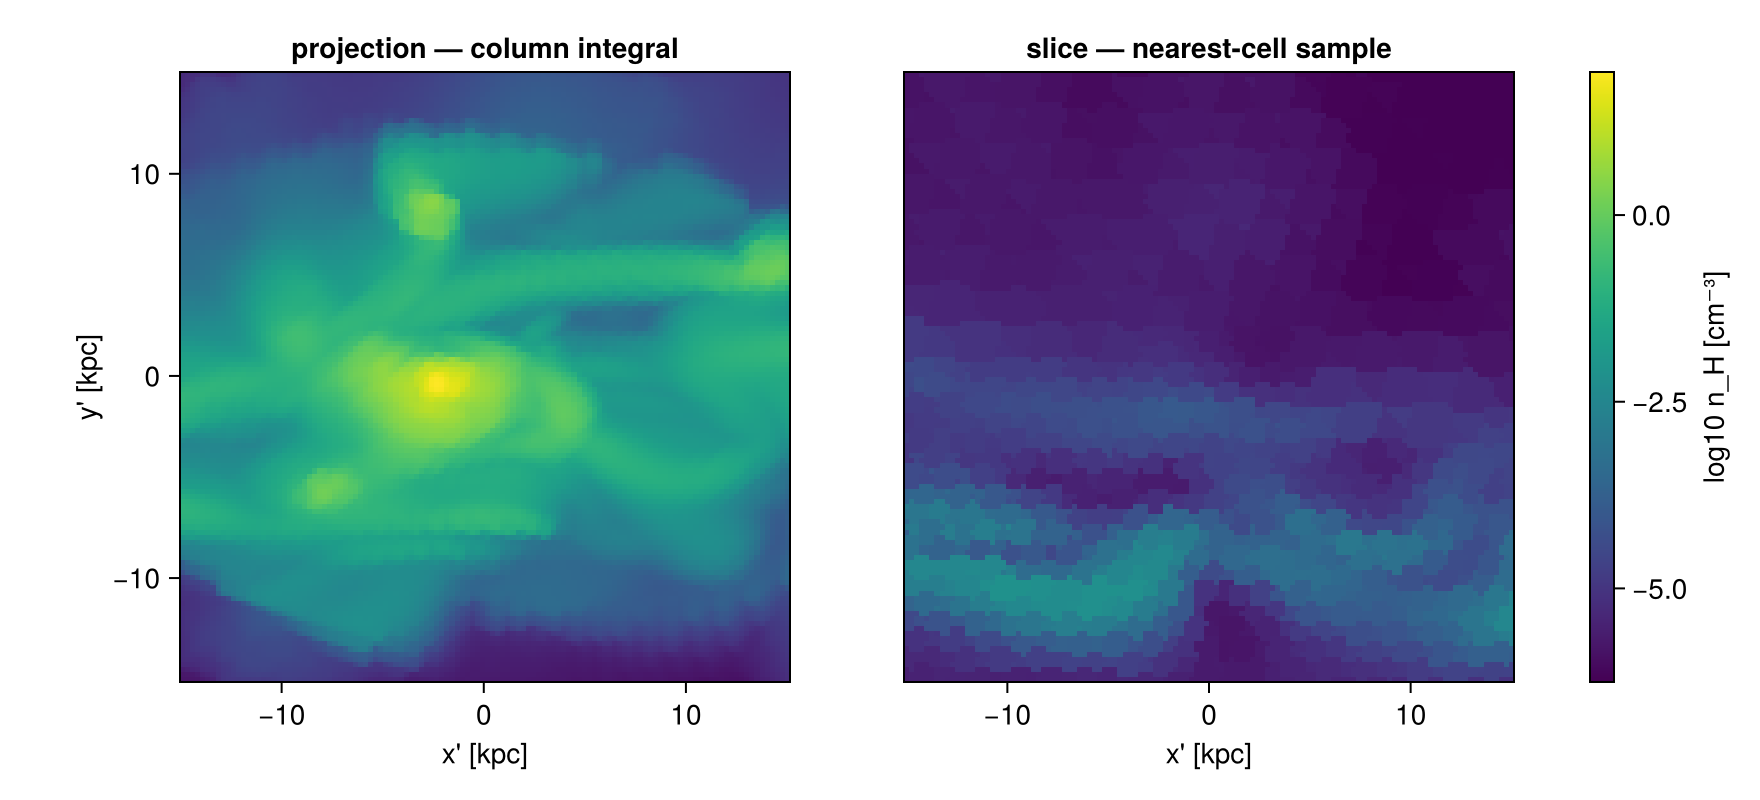

In [19]:
# ── figure code from here: panels, overlays, colorbars, no new Mera concepts ──
As = log10.(replace(Float64.(sl.map), 0.0 => NaN))
Ap = log10.(replace(Float64.(pr.maps[:rho]), 0.0 => NaN))
cr = (quantile(filter(isfinite, vcat(vec(As), vec(Ap))), 0.02),
      maximum(filter(isfinite, vcat(vec(As), vec(Ap)))))
es = sl.extent .* gas.scale.kpc

fig = Figure(size=(880, 400))
ax1 = Axis(fig[1,1], aspect=DataAspect(), title="projection — column integral",
           xlabel="x' [kpc]", ylabel="y' [kpc]")
h = showmap!(ax1, pr, :rho; crange=cr, cmap=:viridis)
ax2 = Axis(fig[1,2], aspect=DataAspect(), title="slice — nearest-cell sample", xlabel="x' [kpc]")
heatmap!(ax2, range(es[1],es[2],length=size(As,1)), range(es[3],es[4],length=size(As,2)),
         As, colormap=:viridis, colorrange=cr, nan_color=:black, interpolate=false)
hideydecorations!(ax2, grid=false)
Colorbar(fig[1,3], h, label="log10 n_H [cm⁻³]")
fig


Two things in the left panel are the *selection* rather than the gas, and both are worth
recognising because they show up in every `fov` projection:

- the soft darkening into the **corners** is the selection sphere, at `fov=15, aperture=:square`
  the corners sit on the sphere and integrate zero depth (see "Choosing `fov`" in Chapter 4);
- any **flat, straight-edged plateau** in the outskirts is a single AMR cell's projected shadow.
  Sample a column integral much finer than the local cell and you resolve individual cell
  footprints, which tile the map and read as overlapping slabs. At 0.25 kpc pixels against
  0.78 kpc cells that is mostly gone; at 0.12 kpc it dominates the outer frame.

Neither is a projection error, mass is conserved either way (Chapter 5). They are what you get
for asking the map a question finer than the data can answer.


## 9. Turning the camera: orbit movies

`rotation_sequence` renders one variable from a list of angles and returns a `Vector` of map objects. `sweep=:azimuth` (default), `:inclination` or `:position_angle` chooses which angle varies.

It uses **the same framing rule as Chapter 4, swept**: a rotation-invariant sphere selection, `aperture=:circle` or `:square`. That is the whole reason it exists, a cubic window's rotated bounding box changes size frame by frame, so the movie breathes.

!!! note "One difference from `projection`"
    Omit `fov` on `rotation_sequence` and it **auto-fits** to the 99 % enclosed-mass radius, so the frame follows the object rather than the sparse outermost cells. `projection` has **no** auto-fit, omit `fov` there and you are back on world ranges. If you learned `fov=22` in Chapter 4 and drop it here, your framing rule silently changes. Pass `fov` explicitly whenever it matters.

`parallel_frames=true` runs the frames concurrently with single-threaded projections instead of the reverse; it is typically ~1.5 to 2× faster when there are at least as many frames as threads, at proportionally more transient memory. Keep the total at or below 8 threads on a laptop.


In [20]:
frames = rotation_sequence(gas, :sd, :Msol_pc2; sweep=:azimuth, angles=0:90:270,
                           inclination=55, axis=:angmom, center=[:bc],
                           fov=22, fov_unit=:kpc, aperture=:square,
                           pxsize=[0.5,:kpc], parallel_frames=false)

# The numerical proof that the frame does not breathe, stronger than watching it.
for (a, f) in zip(0:90:270, frames)
    println("azimuth ", lpad(a,3), "°   frame ", size(f.maps[:sd]),
            "   extent [kpc] = ", round.(getextent(f, :kpc), digits=3))
end


azimuth   0

°   frame (88, 88)   extent [kpc] = [-21.772, 22.009, -21.781, 22.0]
azimuth  90°   frame (88, 88)   extent [kpc] = [-21.817, 21.964, -21.837, 21.944]
azimuth 180°   frame (88, 88)   extent [kpc] = [-21.772, 22.009, -21.925, 21.857]
azimuth 270°   frame (88, 88)   extent [kpc] = [-21.786, 21.995, -21.917, 21.864]


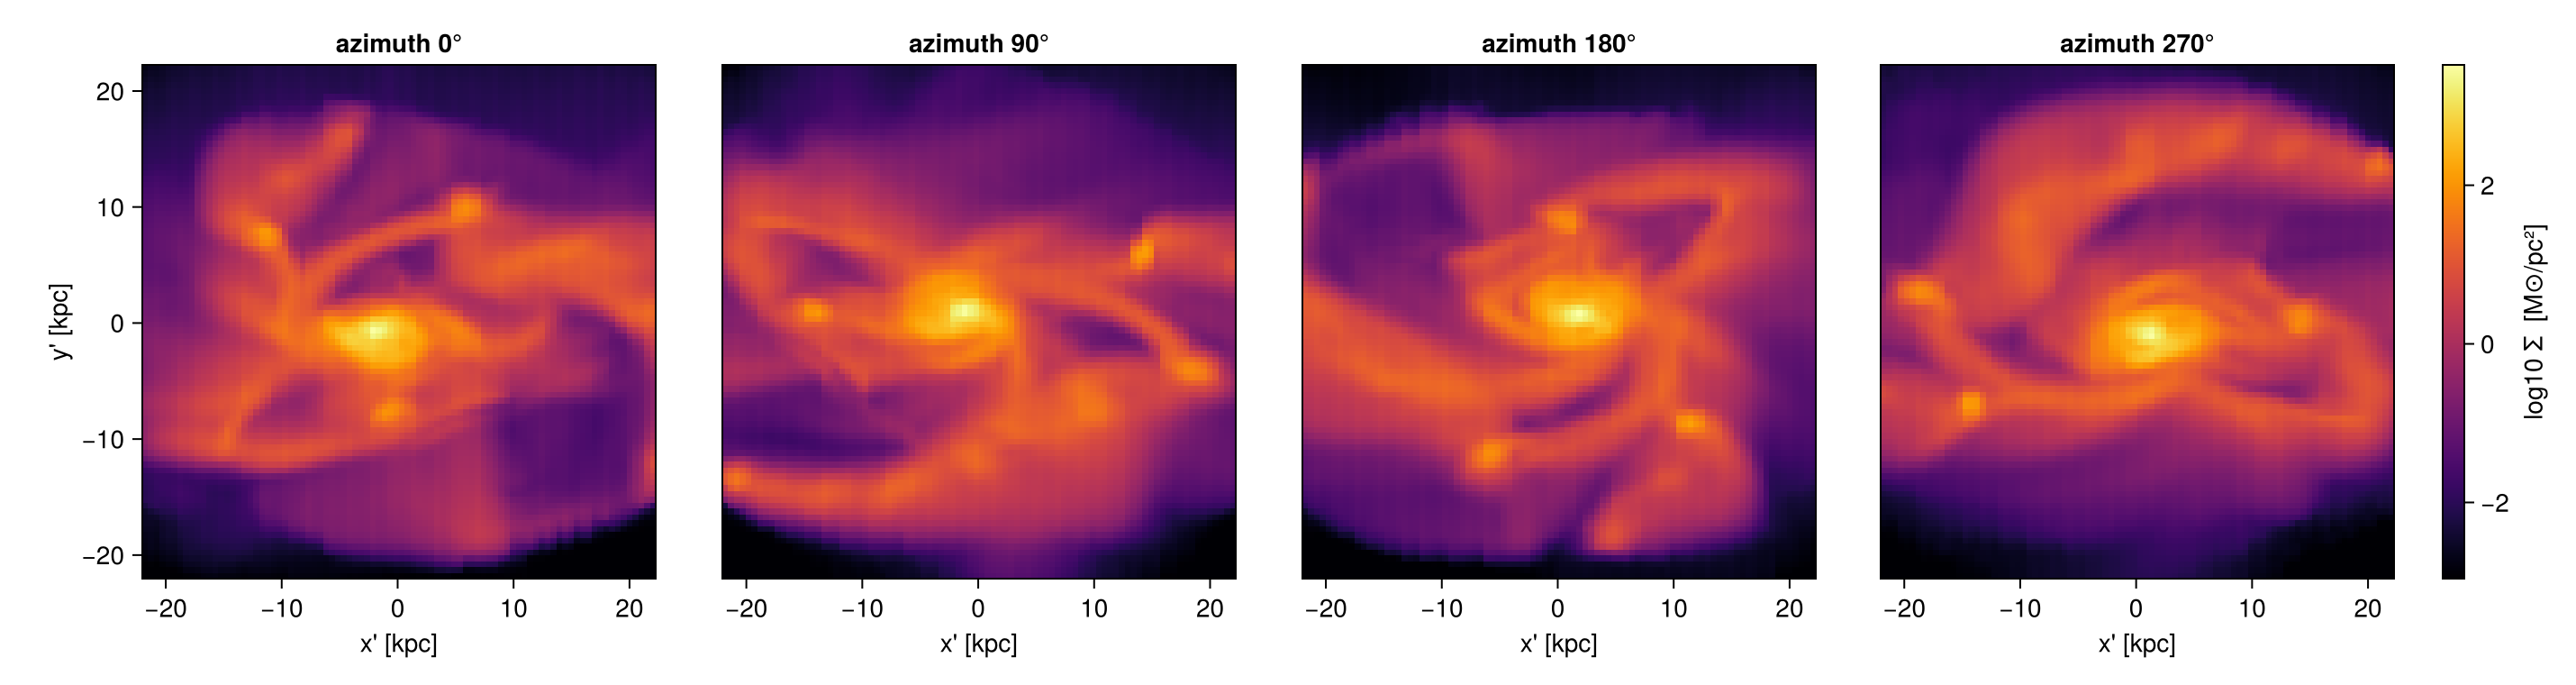

In [21]:
# ── figure code from here: panels, overlays, colorbars, no new Mera concepts ──
# The frames are already computed above; showing them is the visual half of the same claim.
cr = sharedrange(frames, :sd)
maprow(collect(frames), :sd, ["azimuth $(a)°" for a in 0:90:270]; crange=cr)


Four frames, four azimuths, one frame size and one extent to three decimals, the montage and the
numbers say the same thing from opposite directions. That invariance is what makes the sequence
usable as a movie: nothing breathes, so the eye reads rotation rather than zoom.

Write the frames to disk with any Makie/`FileIO` recorder, or hand the vector straight to
`Makie.record`. For a long sweep, `parallel_frames=true` renders the frames concurrently (each
projection single-threaded), typically 1.5 to 2× faster once you have more frames than threads.


Every frame is the same array, the same physical extent and the same pixel scale. Turning that
into a movie is one `Makie.record` call, Makie ships its own ffmpeg through `FFMPEG_jll`, so
this needs nothing installed on the system and runs as part of the notebook:


In [22]:
# Rendered here rather than pasted in, so the movie can never drift from the code above.
#
# The four frames above are for READING: a montage you compare panel by panel. A movie wants many
# more, or the orbit steps rather than turns. 24 frames at 15 degrees is one revolution in three
# seconds at framerate 8, which reads as motion; the four-frame version reads as a slideshow.
# Same camera, same fixed FOV, so nothing else about the sequence changes.
smooth = rotation_sequence(gas, :sd, :Msol_pc2; sweep=:azimuth, angles=0:15:345,
                           inclination=55, axis=:angmom, center=[:bc],
                           fov=22, fov_unit=:kpc, aperture=:square,
                           pxsize=[0.5,:kpc], parallel_frames=false)

cr  = sharedrange(smooth, :sd)          # one colour range across the whole orbit
fig = Figure(size=(360, 360))           # frame COUNT drives smoothness, resolution drives file
                                        # size, so keep 24 frames and shrink the canvas instead
ax  = Axis(fig[1, 1], aspect=DataAspect(), title="orbit movie (fixed FOV, square)")
hidedecorations!(ax)

mkpath("assets/offaxis")
record(fig, "assets/offaxis/orbit_movie.gif", eachindex(smooth); framerate=12) do k
    empty!(ax)
    showmap!(ax, smooth[k], :sd; crange=cr)
end
println("wrote assets/offaxis/orbit_movie.gif  (", length(smooth), " frames, ",
        round(filesize("assets/offaxis/orbit_movie.gif") / 1024, digits=1), " KB)")
println("every frame the same size: ",
        all(size(f.maps[:sd]) == size(smooth[1].maps[:sd]) for f in smooth))

wrote assets/offaxis/orbit_movie.gif  (24 frames, 1967.3 KB)
every frame the same size: true


![Orbit movie, the camera sweeps azimuth at fixed inclination; the frame does not breathe.](assets/offaxis/orbit_movie.gif)


## 10. Reading the result, and fixing a map that looks wrong

Everything you need to debug an off-axis map travels on the result. You already printed the camera in Chapter 1; here is how to read it.

- `m.los`, `m.up`, `m.cam_right`, the basis actually used. If `m.los` is not what you expected, your view specifier or your `center` is the problem, not the renderer.
- `m.center` is a **box fraction** on a map object (a `slice` result's `.center` is code units, different quantity, same field name).
- `m.direction` reads `:offaxis`.
- `m.maps_lmax` is **empty** off-axis by design; `m.maps_weight` exists on AMR map objects only, not on particle ones.
- `m.pixsize` and `m.extent` are code units, use `getextent(m, :kpc)`.

**Orientation fixes.** `position_angle=` rolls the image about `ŵ`; `up=` pins the image-y direction outright. Note that when you write your own loop over hand-made `los=` vectors, the automatic up-vector (the world axis least parallel to `ŵ`) can **flip mid-sweep** and your animation will jump. Fix `up=` explicitly, or use `rotation_sequence`, which sets an up-hint for you.

**Grid diagnostics.** `gridoverlay(gas; level=:max, <same view kwargs>)` draws the AMR structure in the camera frame. Read it honestly: off-axis it draws **cell-size squares at rotated cell centres**, not the true projected hexagonal footprints, so it tells you *where* and *how big* cells are, not what shape their shadows have.


In [23]:
savemap(fo, joinpath(tempdir(), "faceon_sd.jld2"), verbose=false)
fo2 = loadmap(joinpath(tempdir(), "faceon_sd.jld2"), verbose=false)

println("camera survives the round trip : ", fo2.los == fo.los && fo2.up == fo.up)
println(".center (box fraction)         : ", round.(fo.center, digits=3))
println(".maps_lmax off-axis            : ", isempty(fo.maps_lmax) ? "empty (by design)" : "populated")
println(".direction                     : ", fo.direction)


camera survives the round trip : true


.center (box fraction)         : [0.5, 0.5, 0.5]
.maps_lmax off-axis            : empty (by design)
.direction                     : offaxis


**Troubleshooting**, six symptoms, six causes:

| symptom | cause | fix |
|---|---|---|
| `:edgeon` looks face-on, or the disc is tilted at a random angle | L computed about the box corner | pass `center=[:bc]` (Ch 1) |
| "face-on" is off by 10 to 30° for a warped or fountain-rich disc | L over the full box is dominated by slow, high-lever-arm CGM gas | take `:angmom` on an inner-disc `subregion`, then project the full data with that explicit `los=` (App. C) |
| straight edges cut across the map; the frame is bigger than requested | world-space `xrange`/`yrange` | `fov` + `fov_unit` + `aperture=:square` (Ch 4) |
| the galaxy is a dot in a huge frame | `fov` without `fov_unit`, 22 *box lengths*, clamped | always pair them (Ch 4) |
| `projection(gas, :vlos; direction=:z)` errors in `getvar` | `:vlos`/`:σlos` exist only in the off-axis engine | write `los=[0,0,1]` (Ch 5) |
| holes or moiré in a zoomed map | `:cic`/`:ngp` with pixels finer than cells | `binning=:overlap` (Ch 6) |
| an orbit movie tumbles across snapshots | `direction=:faceon` recomputed per snapshot; L drifts | freeze one `los=` (App. C) |

And when re-plotting is the slow part, do not re-project: `savemap` / `loadmap` round-trip the whole object, every map and unit, the geometry, the camera basis and the simulation `info`.


## 11. The same camera on other data

The view keywords are the same everywhere. What differs is a short list of defaults and gaps, all in one table:

| | hydro / RT | particles |
|---|---|---|
| `binning` default | `:overlap` | **`:cic`**; `:overlap`/`:exact` fall back to `:cic` (points have no footprint) and say so once per session |
| `weighting` | **Array**, `[:mass, missing]` | **Symbol**, `:mass`, `:volume`, `:sph`, `:voronoi`, all available off-axis. `:sph` conserves mass to ~0.2 % independent of angle; `:voronoi` trades that for sharp cell edges (~3 % angle spread), so prefer `:sph` for quantitative maps |
| `fov` / `fov_unit` / `aperture` | yes | **yes**, same rotation-invariant sphere selection; the framing is a selection, so it does not care what is deposited |
| `mode`, `nmax`, `max_threads`, `gravity_data` | yes | absent |
| `data_center` | **silently ignored** on the off-axis hydro path | honoured |
| `slice` | yes, with `offset` to move the plane | no, and by design: a plane through points is empty. Use `thickness`/`offset` on `projection` for a slab |
| `thickness` / `offset` | not applicable (a slice is the cell equivalent) | **yes**, project a slab of finite depth and move it along the line of sight |

Gravity goes through the combined call form `projection(hydro, gravity, var; …)`. RT data has no velocity field, so `:angmom`, `:faceon` and `:edgeon` are unavailable, give an explicit `los=`, or take `[:lx,:ly,:lz]` from the matching hydro object with `getvar` and pass the result as `axis=[lx,ly,lz]`. (This fixture has no RT output; see the [radiative transfer page](10_multi_RadiativeTransfer.md).)


In [24]:
part = getparticles(info, verbose=false, show_progress=false)
ps = projection(part, :sd, :Msol_pc2; direction=:edgeon, center=[:bc],
                xrange=[-20,20], yrange=[-20,20], zrange=[-20,20], range_unit=:kpc,
                pxsize=[0.4,:kpc], verbose=false, show_progress=false)
println("stars   : frame ", size(ps.maps[:sd]), "   los = ", round.(ps.los, digits=3))

grav = getgravity(info, verbose=false, show_progress=false)
pe = projection(gas, grav, :epot; direction=:faceon, center=[:bc],
                xrange=[-20,20], yrange=[-20,20], zrange=[-20,20], range_unit=:kpc,
                pxsize=[0.4,:kpc], verbose=false, show_progress=false)
# NB the raw extrema read (-0.53, 0.0), that 0.0 is EMPTY pixels, not a physical potential.
# Report the filled pixels, and say how many were empty.
epot = pe.maps[:epot]; filled = filter(<(0), epot)
println("gravity : maps ", collect(keys(pe.maps)))
println("          epot over filled pixels ", round.(extrema(filled), sigdigits=4),
        "   (", count(iszero, epot), " of ", length(epot), " pixels empty)")


stars   : frame (

107, 109)   los = [0.999, -0.002, -0.037]


gravity : maps Any[:epot, :sd]
          epot over filled pixels (-0.5327, -0.03714)   (530 of 11448 pixels empty)


### A slab instead of a slice, for particles

A cutting plane through point particles catches nothing: a particle has no extent, so a
zero-thickness plane is empty by construction. That is why `slice(part, …)` is a `MethodError`
rather than an oversight.

The useful analogue is a projection of finite depth. `thickness` sets the depth of the slab along
the line of sight and `offset` moves it, the same way `offset` moves the plane for cell data. A
non-positive thickness is refused rather than returning an empty map.

In [25]:
S = (direction=:edgeon, center=[:bc], fov=15, fov_unit=:kpc, aperture=:square,
     pxsize=[0.5,:kpc], verbose=false, show_progress=false)
full = projection(part, :sd, :Msol_pc2; S...)
T = sum(full.maps[:sd])
println(rpad("thickness [kpc]", 18), rpad("total", 12), "fraction of the full column")
for th in (20.0, 5.0, 1.0)
    m = projection(part, :sd, :Msol_pc2; thickness=th, thickness_unit=:kpc, S...)
    println(rpad(th, 18), rpad(round(sum(m.maps[:sd]), sigdigits=6), 12),
            round(sum(m.maps[:sd])/T, digits=4))
end

println()
println(rpad("offset [kpc]", 18), "total in a 2 kpc slab")
for off in (-6.0, -2.0, 0.0, 2.0, 6.0)
    m = projection(part, :sd, :Msol_pc2; thickness=2.0, thickness_unit=:kpc,
                   offset=off, offset_unit=:kpc, S...)
    println(rpad(off, 18), round(sum(m.maps[:sd]), sigdigits=6))
end

thickness [kpc]   total       

fraction of the full column
20.0              273951.0    

0.9052
5.0               178911.0    0.5912
1.0               28693.2     

0.0948

offset [kpc]      total in a 2 kpc slab
-6.0              11801.2


-2.0              115805.0
0.0               67432.2
2.0               

16791.2
6.0               5921.15


The slab total rises with thickness, as it must. The offset sweep is more interesting: the mass
peaks at **-2 kpc**, not at 0. That is not a bug in the slab, it is the slab reporting where the
stars actually are. `center=[:bc]` is the box centre, and this galaxy's stellar centroid does not
sit exactly there, so the densest slab is the one offset toward it.

That is the check worth running on your own data. If the peak is not where you expect the object
to be, either the centre is wrong or the object is not where you think, and both are worth knowing
before you quote a number from the map.

gas   frame (67, 67)   stars (67, 67)   potential (67, 67)
φ along the line of sight: (-1976.0, -175.5) km²/s²


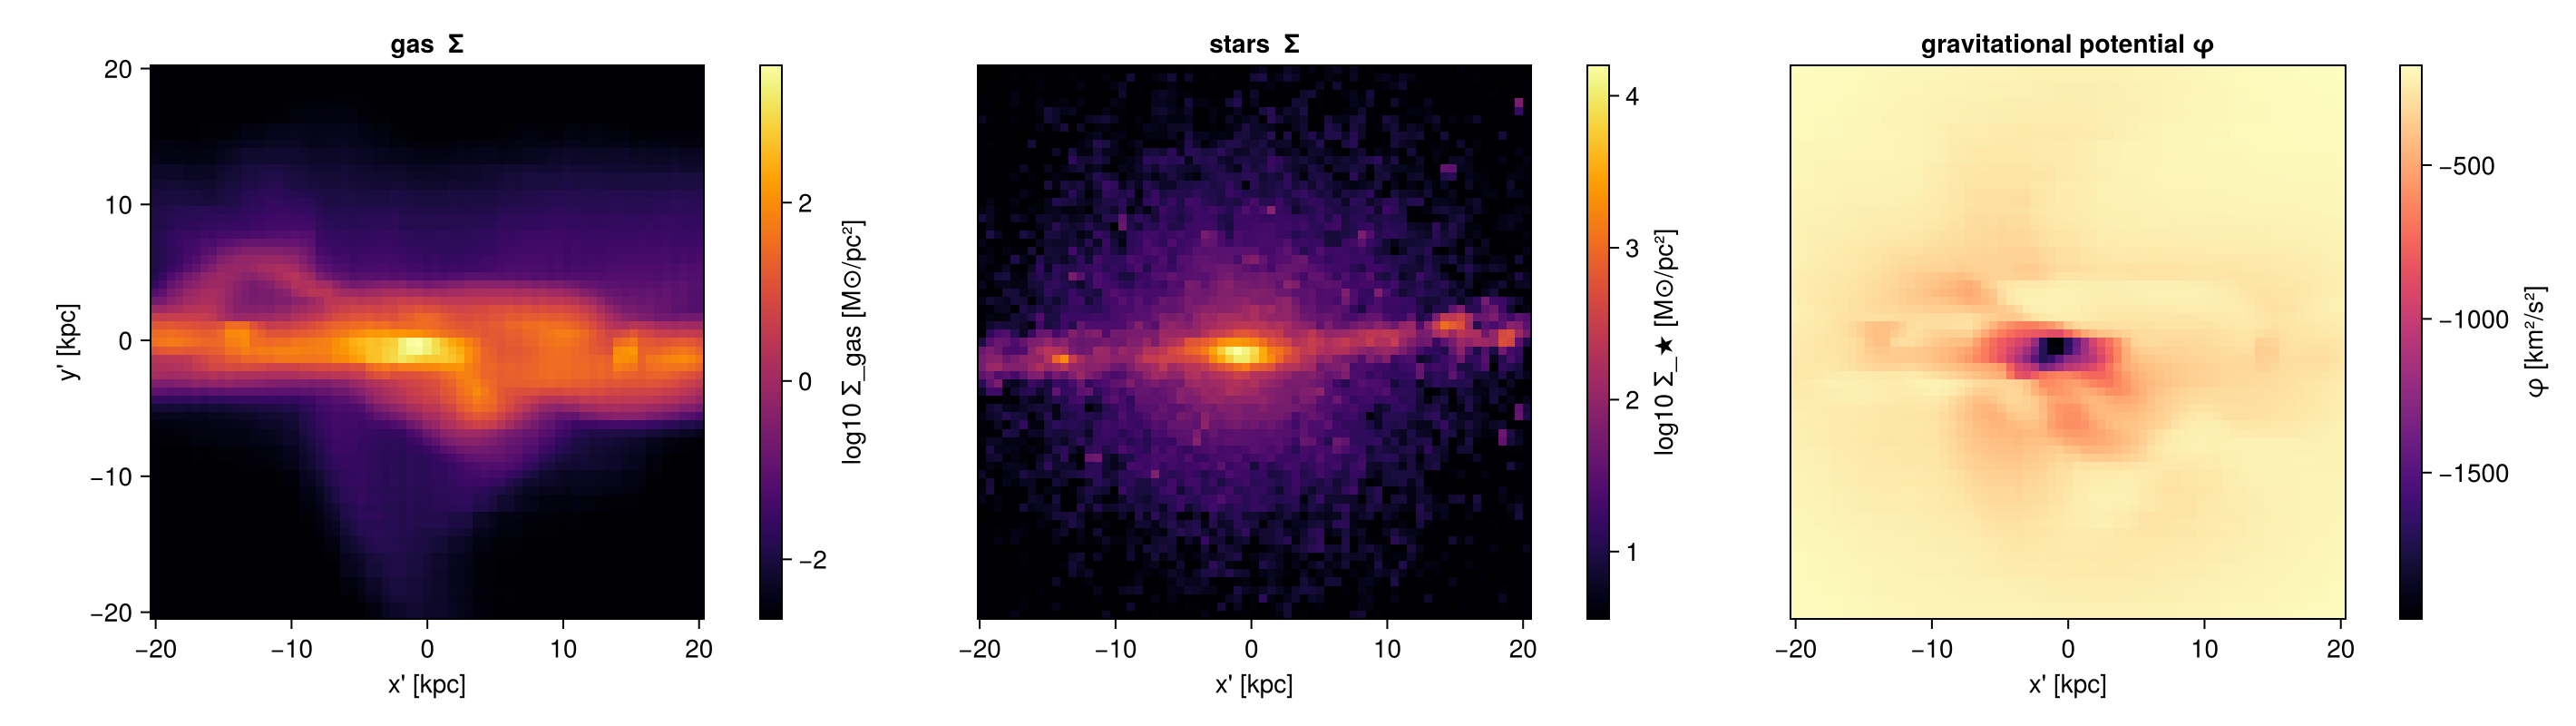

In [26]:
# The same camera, pointed at a different data type. `fov` frames both identically, so the two
# panels can be compared pixel for pixel.
# 0.6 kpc pixels: fine enough to show both discs, coarse enough that the STAR map is not
# dominated by Poisson noise (453 200 particles, the outskirts get very few per pixel)
shot = (direction=:edgeon, center=[:bc], fov=20, fov_unit=:kpc, aperture=:square,
        pxsize=[0.6, :kpc], verbose=false, show_progress=false)
gas_eo  = projection(gas,  :sd, :Msol_pc2; shot...)
star_eo = projection(part, :sd, :Msol_pc2; shot...)
# gravity rides on the hydro grid: the two-object form, same camera, same framing
pot_eo  = projection(gas, grav, :epot, :km2_s2; shot...)
println("gas   frame ", size(gas_eo.maps[:sd]),
        "   stars ", size(star_eo.maps[:sd]),
        "   potential ", size(pot_eo.maps[:epot]))
println("φ along the line of sight: ", round.(extrema(pot_eo.maps[:epot]), sigdigits=4), " km²/s²")


# ── figure code from here: panels, overlays, colorbars, no new Mera concepts ──
# separate colour ranges: gas and stars differ by orders of magnitude in surface density,
# and forcing one scale would flatten whichever loses
lo(m) = quantile(log10.(filter(>(0), vec(Float64.(m.maps[:sd])))), 0.25)  # clip the empty rim
hi(m) = maximum(log10.(filter(>(0), vec(Float64.(m.maps[:sd])))))

fig = Figure(size=(1420, 400))
ax1 = Axis(fig[1,1], title="gas  Σ", xlabel="x' [kpc]", ylabel="y' [kpc]")
h1 = showmap!(ax1, gas_eo, :sd; crange=(lo(gas_eo), hi(gas_eo)))
Colorbar(fig[1,2], h1, label="log10 Σ_gas [M⊙/pc²]")

ax2 = Axis(fig[1,4], title="stars  Σ", xlabel="x' [kpc]")
h2 = showmap!(ax2, star_eo, :sd; crange=(lo(star_eo), hi(star_eo)))
Colorbar(fig[1,5], h2, label="log10 Σ_★ [M⊙/pc²]")

# the potential is negative everywhere and spans a small range, a linear scale on the raw
# value, no log, and a sequential map so "deeper" reads as one direction
ax3 = Axis(fig[1,7], title="gravitational potential φ", xlabel="x' [kpc]")
h3 = showmap!(ax3, pot_eo, :epot; logscale=false, cmap=:magma)
Colorbar(fig[1,8], h3, label="φ [km²/s²]")

hideydecorations!(ax2, grid=false); hideydecorations!(ax3, grid=false)
colsize!(fig.layout, 3, Fixed(14)); colsize!(fig.layout, 6, Fixed(14))
fig


Same keywords, same camera, three different kinds of data, and each one says something the
others cannot. The stars form a **thinner, smoother disc** than the gas, which is exactly the
comparison that motivates making both maps in one orientation. The potential is smoother than
either: it is an integral over all the mass, so it does not care about the clumps that dominate
the gas map, and its contours are rounder than the disc that produced them.

Gravity comes through the **two-object form**, `projection(hydro, gravity, var)`: the hydro object
supplies the weights and the gravity object the field, so both must describe the same cells,
load them from the same `info` at the same `lmax`. `fov` cuts both together, so the three panels
above are framed identically and can be compared pixel for pixel.

`fov` works for particles as it does for the grid, the framing is a selection, so it does not care
what is being deposited. What *does* differ is the deposit itself: points have no footprint, so
particle projections use `:cic` and the footprint kernels fall back to it.

That difference is visible if you push the pixels: a grid map degrades smoothly, while a particle
map becomes **grainy**, because each pixel is counting a finite number of objects and inherits a
√N uncertainty. The cure is the same as in any counting experiment, coarsen the pixels until each
one holds enough particles to mean something.


In [27]:
# The table above is a set of claims. Run them, a compatibility table that is never executed
# is exactly the kind of thing that goes stale when the code moves on.
W = (center=[:bc], xrange=[-15,15], yrange=[-15,15], zrange=[-15,15], range_unit=:kpc,
     pxsize=[1.0,:kpc], verbose=false, show_progress=false)
same(a, b) = maximum(abs, a.maps[:sd] .- b.maps[:sd]) == 0
raises(f)  = try (f(); "NO ERROR") catch e; string(typeof(e).name.name) end

pc = projection(part, :sd, :Msol_pc2; direction=:edgeon, binning=:cic, W...)
println("particle binning=:overlap falls back to :cic : ",
        same(projection(part, :sd, :Msol_pc2; direction=:edgeon, binning=:overlap, W...), pc))
println("particle binning=:exact   falls back to :cic : ",
        same(projection(part, :sd, :Msol_pc2; direction=:edgeon, binning=:exact, W...), pc))
# :sph/:voronoi now work off-axis too: both are rotation-invariant, so the same samplers run
# on camera-frame coordinates. (They need a :volume column, which star particles lack.)
for w in (:sph, :voronoi)
    println(rpad("weighting=:$w off-axis (needs :volume)", 45), ": ",
            raises(() -> projection(part, :sd, :Msol_pc2; direction=:edgeon, weighting=w, W...)))
end
println("fov works on particles                       : ",
        size(projection(part, :sd, :Msol_pc2; direction=:edgeon, center=[:bc], fov=15,
                        fov_unit=:kpc, aperture=:square, pxsize=[1.0,:kpc],
                        verbose=false, show_progress=false).maps[:sd]))
println("slice(part, …)                               : ",
        raises(() -> slice(part, :sd; direction=:edgeon, center=[:bc], xrange=[-15,15],
                           yrange=[-15,15], range_unit=:kpc, pxsize=[1.0,:kpc], verbose=false)))
for kw in (:nmax, :max_threads)
    println(rpad(string("particle ", kw), 45), ": ",
            raises(() -> projection(part, :sd, :Msol_pc2; direction=:edgeon, (; kw => 8)..., W...)))
end
println("data_center ignored on off-axis hydro        : ",
        same(projection(gas, :sd, :Msol_pc2; inclination=35, axis=:angmom, W...),
             projection(gas, :sd, :Msol_pc2; inclination=35, axis=:angmom,
                        data_center=[0.4,0.4,0.4], data_center_unit=:standard, W...)))


particle binning=:overlap falls back to :cic : true


particle binning=:exact   falls back to :cic : true
weighting=:sph off-axis (needs :volume)      : 

ArgumentError
weighting=:voronoi off-axis (needs :volume)  : 

ArgumentError
fov works on particles                       : (30, 30)
slice(part, …)                               : MethodError
particle nmax                                : MethodError
particle max_threads                         

: NO ERROR


data_center ignored on off-axis hydro        : true


Nothing above is hydro-specific. The camera keywords, the framing keywords and the binning
keywords mean the same thing for every projectable data type:

* **particles**, point masses, deposited with the same kernels; `:sd` is a stellar surface
  density here rather than a gas one;
* **gravity**, projected through the two-object form `projection(hydro, gravity, var)`, where the
  hydro object supplies the weights and the gravity object the field. Both must describe the same
  cells, so load them from the same `info` at the same `lmax`.

The empty-pixel count printed above is worth carrying with you: an off-axis frame that is *not*
completely filled is normal, and the zeros are absence of data, not zero potential. Aggregate the
filled pixels, not the whole array.


## Appendix A, Limitations, in one place

The one limitations table. Twelve rows, one line each. Nothing here is repeated anywhere else in the notebook.

| | |
|---|---|
| **Orthographic only** | parallel rays, observer at infinity. No perspective, no observer-inside-the-box view. |
| **No line-of-sight depth slab** | `xrange`/`yrange`/`zrange` are world-space; the frame always auto-fits the rotated footprint. `zrange` clips world *z*, and only coincides with depth near a ±z line of sight. |
| **`zrange` can be a no-op** | an axis whose requested range already covers the loaded data's range is not clipped at all. |
| **Slab edges are cell-centre cuts** | cells are kept or dropped by their centre; straddlers are not clipped, so a world-range selection is accurate to about one cell size per face (3.1 kpc at level 5 here). |
| **Border fold-back** | stencils crossing the map edge fold onto the edge pixel, the outermost row/column of any off-axis map is not a clean measurement. |
| **`fov` footguns** | `fov_unit` defaults to a box fraction; `fov` replaces `xrange`/`yrange`/`zrange`; `center` is then read in `fov_unit`; `fov` cannot be combined with a per-cell `mask`. |
| **Frames match, but not bit-exactly** | `aperture=:square` gives identical pixel dimensions and identical physical scale at every angle; co-registration is good to the auto-fit rounding, not to the bit. |
| **`nmax=64`** | zoom far enough into a coarse-AMR region and `:overlap` deposits a footprint-sized top-hat rather than a 64³ sub-point lattice. Detect by raising `nmax`, or use `:exact` (no cap). |
| **Off-axis ≠ axis-aligned pixel grids** | differencing `los=[0,0,1]` against `direction=:z` shows a sub-pixel origin offset. That is a grid convention, not an error. |
| **Variables unavailable off-axis** | `:σx :σy :σz :σ :σr_cylinder :σϕ_cylinder :r_cylinder :r_sphere :ϕ`, use `direction=:x/:y/:z`. |
| **Result-object quirks** | `maps_lmax` is empty off-axis; `maps_weight` is AMR-only; `.center` is a box fraction on a map but code units on a `slice`; a mass-weighted call returns a bonus `:sd` map; `lmax` off-axis only sets the default resolution and never coarsens the data. |
| **Shipped separately** | column integrals, emission/absorption, PPV cubes, mock observations and FITS export are in development in a separate module, not in the released package. |


## Appendix B, Where the guarantees are measured

Two claims on this page are load-bearing, so neither rests on prose.

**Mass is conserved at any angle and any pixel size.** Every binning mode is a partition-of-unity
deposit: each cell distributes its full weight across the pixels of the camera plane with shares
that sum to exactly 1, so the total deposited weight is `Σ m_cell` regardless of *where* the cells
land. Rotating the camera or changing the pixel grid only moves weight between pixels; it never
creates or destroys any. Cells whose stencil reaches past the border fold the outside share back
onto the edge pixel, so the sum is preserved rather than leaking. For `:overlap` the same argument
holds per sub-point, and for `:exact` the per-pixel footprint integrals are renormalised to the
cell volume, so the conserved total is exact by construction in both.

Chapter 5 measures it once on this dataset: `Σ(map) / msum(gas) − 1 = 0.0`.

**The kinematics recover the right axis.** `:vlos` is antisymmetric about the minor axis edge-on
and near-zero face-on, the check in Chapter 7, which is also how you detect a mis-centred
`center` before it silently tilts every map you make.

Both are pinned by the test suite rather than by this page, over a grid of viewing angles, pixel
sizes (including non-power-of-two) and binning kernels, see `test/34_offaxis_invariance_tests.jl`
and `test/68_offaxis_api_tests.jl` in the repository. If a change ever broke one of them, the
suite would fail before the documentation did.


## Appendix C, Recipe: one fixed orientation across a time series

The most common way a multi-snapshot off-axis analysis goes wrong: `direction=:faceon` is called per snapshot, the disc's L drifts (warp, bar, merger, an infalling satellite), and the resulting movie tumbles or the measured inclination wanders.

The fix is to compute the orientation **once**, on the region you actually mean, and then freeze it:

```julia
# NOT EXECUTED — this fixture ships a single output (output_00100).
# Shown for the mechanics; substitute your own output list.

# 1. Orientation from the INNER DISC of one reference snapshot, not the whole box.
#    L over the full box is dominated by slow, high-lever-arm CGM gas, which is
#    why a whole-box "face-on" can be 10–30° off for a warped or fountain-rich disc.
ref  = gethydro(getinfo(100, path, verbose=false), verbose=false, show_progress=false)
disc = subregion(ref, :cylinder, radius=8., height=2., range_unit=:kpc,
                 center=[:bc], verbose=false)
Lfix = [sum(getvar(disc, :lx, center=[:bc])),
        sum(getvar(disc, :ly, center=[:bc])),
        sum(getvar(disc, :lz, center=[:bc]))]
Lfix ./= sqrt(sum(abs2, Lfix))

# 2. Project every snapshot with that ONE frozen line of sight and a fixed FOV.
#    `up=` is pinned too, so the auto-up tie-break cannot flip mid-series.
for out in outputs
    g = gethydro(getinfo(out, path, verbose=false), verbose=false, show_progress=false)
    m = projection(g, :sd, :Msol_pc2; los=Lfix, up=[0,0,1], center=[:bc],
                   fov=22, fov_unit=:kpc, aperture=:square, pxsize=[0.3,:kpc],
                   verbose=false, show_progress=false)
    savemap(m, "faceon_$(out).jld2", verbose=false)
end
```

Gas L and stellar L are not the same vector (bars, warps, counter-rotating components), so decide which tracer defines your frame and stick to it. And note that this is also how you get a *comparable* frame: the same `los`, the same `fov`, the same `pxsize`, so every snapshot is the same camera.
